# NLP01 프로젝트 - 한국어를 영어로 번역하는 seq2seq 번역기

내가 노드에서 배운 seq2seq + Attention 구조를 PyTorch로 직접 짜서,
**한국어 문장을 영어로 번역하는 모델**을 만든다.

## 이 프로젝트가 뭐냐면
한영 병렬 말뭉치(korean-english-park, 문장 9만 4천 쌍)를 가지고,
"개인용 컴퓨터..." <-> "Much of personal computing..." 처럼 짝지어진 문장으로
번역을 학습시킨다. 학습이 끝나면 "오바마는 대통령이다." 같은 새 문장을 넣어
영어로 뱉게 하는 게 목표다.

## 이 노트북에서 만드는 것
1. 한영 병렬 데이터 내려받고, 한글까지 되는 전처리로 정제
2. 한글은 형태소(mecab), 영어는 단어(split) 단위로 토큰화
3. Bahdanau Attention 을 단 seq2seq(GRU) 모델 설계
4. teacher forcing 으로 학습시키고, loss 가 떨어지는지 확인
5. 예문 4개를 직접 번역시키고, Attention Map 으로 어디를 보고 번역했나 시각화
6. 회고

## 전체 흐름
내가 노드에서 잡은 그림은 이거다. 코드도 이 순서로 간다.
```
 전체 흐름:  [데이터]  ──→  [모델]  ──→  [확인]

 [데이터]                      [모델]                       [확인]
 Step0 라이브러리 버전          Step4 Attention seq2seq      Step5 학습(teacher forcing)
 Step1 데이터 다운로드             - BahdanauAttention           - loss 하락 확인
 Step2 정제(중복/한글정규식)        - Encoder(GRU)                - 예문 4개 번역
 Step3 토큰화(형태소/split)       - Decoder(GRU+attn)           - Attention Map
                                  - Seq2Seq 묶기
```

## 먼저 알아둘 말 (용어 메모)
- **병렬 말뭉치(parallel corpus)** : 같은 뜻의 두 언어 문장을 짝지어 둔 데이터. 한 줄끼리 짝이다.
- **형태소 분석** : 한국어는 "오바마는"처럼 단어가 붙어 있어서, "오바마/는"으로 의미 단위를 쪼개야 한다. 그 도구가 mecab 이다.
- **teacher forcing** : 학습할 때 디코더에 직전 *예측* 대신 *정답* 단어를 넣어주는 방식. 예) 정답이 `<start> i am a student <end>` 면, 매 단계 **입력**은 항상 정답의 직전 단어(<start>→i→am→a→...)로 넣는다. 모델이 중간에 틀리게 예측해도 그건 **채점(loss)에만** 쓰고 **다음 입력엔 안 먹인다**(정답을 넣음). 초반 엉터리 예측이 눈덩이처럼 번지는 걸 막아 학습이 빠르고 안정적이다. (추론 땐 정답이 없어 자기 예측을 도로 먹어서 exposure bias 가 생긴다.)
- **exposure bias** : teacher forcing 의 그림자. 학습 땐 디코더가 늘 *정답* 직전 단어를 받아 "완벽한 앞 단어" 상황만 연습하는데, 추론 땐 정답이 없어 *자기 예측*을 도로 받는다. 모델은 학습 중 "자기가 틀린 단어를 입력으로 받는 상황"을 한 번도 안 겪어봐서(=노출 안 됨), 추론에서 한 번 삐끗하면 처음 보는 맥락에 빠져 오류가 눈덩이처럼 번진다 -> 반복·딴소리·환각. 예) <start>->"you"(틀림)->다음 입력 "you"인데, 학습 땐 그 자리에 늘 "i"였어서 "you..." 맥락은 처음이라 줄줄이 무너짐. (Step6 에서 디코딩 단계로 완화, beam search·scheduled sampling 도 대응책.)
- **Attention** : 디코더가 단어를 하나 만들 때마다, 입력 문장의 어느 부분을 볼지 가중치를 매기는 것. context 벡터 1개로 다 욱여넣던 bottleneck(병목 — 긴 문장을 벡터 하나에 담으려니 정보가 눌리는 것) 을 푼다.


## Step 0. 라이브러리 버전 확인

먼저 이 노트북을 돌린 환경의 핵심 라이브러리 버전을 적어둔다.
나중에 내가(또는 동료가) 재현할 때 버전이 안 맞아 헤매는 걸 막으려는 거다.

In [28]:
# 과제에서 요구한 세 라이브러리 버전부터 확인한다
import pandas
import torch
import matplotlib

print("pandas:", pandas.__version__)
print("torch:", torch.__version__)
print("matplotlib:", matplotlib.__version__)

pandas: 3.0.3
torch: 2.9.1+rocm7.2.1.gitff65f5bc
matplotlib: 3.10.9


In [29]:
# 이 노트북에서 쓸 라이브러리를 한 번에 불러온다
import os                # 파일 경로 다루기
import re                # 정규식 (전처리)
import urllib.request    # 데이터 다운로드
import tarfile           # tar.gz 압축 해제
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from mecab import MeCab            # 한글 형태소 분석기
from collections import Counter    # 단어 빈도 세기 (직접 만든 토크나이저용)
from tqdm import tqdm

# GPU 가 있으면 GPU 로 (학습이 훨씬 빠르다)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Attention Map 그릴 때 한글이 깨지지 않게 나눔폰트 지정
fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
if os.path.exists(fontpath):
    fontprop = fm.FontProperties(fname=fontpath)
    plt.rcParams["font.family"] = fontprop.get_name()
plt.rcParams["axes.unicode_minus"] = False

device: cuda


## Step 1. 데이터 다운로드

한영 병렬 말뭉치 `korean-english-park.train.tar.gz` 를 내려받는다.
압축을 풀면 한국어 파일(`.ko`)과 영어 파일(`.en`)이 나오는데,
두 파일의 같은 줄 번호끼리가 서로 번역 짝이다.

In [30]:
# 데이터를 둘 폴더 (노트북과 같은 위치의 work/ 안)
data_dir = "work/ko_translation"
os.makedirs(data_dir, exist_ok=True)
tar_path = os.path.join(data_dir, "korean-english-park.train.tar.gz")

# 아직 안 받았으면 내려받는다
if not os.path.exists(tar_path):
    url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"
    print("데이터 다운로드 중...")
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료")

# 압축 해제 (한국어/영어 파일이 안 풀려 있으면)
ko_path = os.path.join(data_dir, "korean-english-park.train.ko")
en_path = os.path.join(data_dir, "korean-english-park.train.en")
if not (os.path.exists(ko_path) and os.path.exists(en_path)):
    with tarfile.open(tar_path) as tar:
        tar.extractall(data_dir)
    print("압축 해제 완료")
print(os.listdir(data_dir))

['korean-english-park.train.en', 'kor-eng.tar.gz', 'korean-english-park.train.ko', 'korean-english-park.train.tar.gz', 'cache']


In [31]:
# 한국어/영어 파일을 줄 단위로 읽어 리스트로 만든다
ko_lines = open(ko_path, encoding="utf-8").read().splitlines()
en_lines = open(en_path, encoding="utf-8").read().splitlines()

print("한국어 문장 수:", len(ko_lines))
print("영어 문장 수  :", len(en_lines))
print()
# 같은 줄 번호끼리 번역 짝인지 눈으로 확인
for i in range(2):
    print("[KO]", ko_lines[i])
    print("[EN]", en_lines[i])
    print()

한국어 문장 수: 94123
영어 문장 수  : 94123

[KO] 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
[EN] Much of personal computing is about "can you top this?"

[KO] 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
[EN] so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.



## Step 2. 데이터 정제

세 가지를 한다.
1. **중복 제거** : 같은 문장 쌍이 여러 번 들어 있을 수 있다. `set` 이 중복을 허용 안 하는 성질을 써서 없앤다.
   이때 한국어/영어를 따로 set 에 넣으면 짝이 흐트러지니, **(한, 영) 쌍을 통째로** 묶어서 넣는다.
2. **전처리** : 구두점을 단어와 띄우고, 영어는 소문자로, 한글은 형태소로 쪼갠다. 타겟인 영어엔 `<start>`/`<end>` 토큰을 붙인다.
3. **길이 선별** : 토큰 길이가 40 이하인 짧은 문장만 남긴다. 모든 데이터를 쓰면 학습이 너무 오래 걸려서다.

In [32]:
# (한국어, 영어) 쌍을 통째로 set 에 넣어 중복 제거 -> 병렬 짝이 안 흐트러진다
raw_pairs = list(zip(ko_lines, en_lines))
cleaned_corpus = list(set(raw_pairs))

print("중복 제거 전:", len(raw_pairs))
print("중복 제거 후:", len(cleaned_corpus))

중복 제거 전: 94123
중복 제거 후: 78968


In [33]:
# 전처리 함수 두 개 (한글용 / 영어용).
#  re.sub(패턴, 바꿀것, 문자열) = "패턴에 맞는 부분을 바꿀것으로 치환". r"..." = raw string(백슬래시 그대로; 정규식엔 \ 가 많아 r 을 붙임).
mecab = MeCab()  # 한글 형태소 분석기

def preprocess_korean(sentence):
    s = sentence.strip()                              # 앞뒤 공백 제거
    # ([?.!,]) : ? . ! , 중 한 글자를 "그룹"으로 잡는다.  바꿀것 r" \1 " 의 \1 = 방금 잡은 그 글자.
    #   즉 구두점을 "(공백)그글자(공백)" 으로 -> 구두점을 양옆으로 띄운다 ("끝." -> "끝 . ")
    s = re.sub(r"([?.!,])", r" \1 ", s)
    # [^...] : 대괄호 안 맨 앞 ^ 는 "이것들 빼고" 라는 뜻. 가-힣(한글)·a-zA-Z·0-9·?.!, 만 남기고
    #   + : 1글자 이상 연속. 즉 그 외 문자(특수기호 등)가 이어진 덩어리를 공백 1개로 바꾼다.
    s = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", s)
    # \s+ : 공백(스페이스/탭/줄바꿈)이 1개 이상 연속 -> 공백 1개로 (위에서 생긴 중복 공백 정리)
    s = re.sub(r"\s+", " ", s).strip()
    return mecab.morphs(s)                            # mecab 으로 형태소 단위 토큰 리스트 반환

def preprocess_english(sentence):
    s = sentence.lower().strip()                      # 영어는 소문자로 통일 (The == the 로 보게)
    s = re.sub(r"([?.!,])", r" \1 ", s)               # 구두점 양옆 띄우기 (위와 동일)
    s = re.sub(r"[^a-z0-9?.!,]+", " ", s)             # 영소문자·숫자·구두점만 남김 (이미 소문자라 a-z)
    s = re.sub(r"\s+", " ", s).strip()                # 중복 공백 정리
    return ["<start>"] + s.split() + ["<end>"]        # 타겟(영어)엔 시작/끝 토큰을 붙인다 (split: 공백으로 단어 나누기)

# 전처리가 어떻게 되는지 한 문장으로 확인
print("한국어:", preprocess_korean("오바마는 대통령이다."))
print("영어  :", preprocess_english("Obama is the President."))

한국어: ['오바마', '는', '대통령', '이', '다', '.']
영어  : ['<start>', 'obama', 'is', 'the', 'president', '.', '<end>']


In [ ]:
# 전체를 전처리하면서, 토큰 길이 40 이하인 쌍만 골라 담는다. 프로젝트 요구사항.
MAX_LEN = 40

kor_corpus, eng_corpus = [], []
for ko, en in tqdm(cleaned_corpus, desc="전처리"):   # tqdm: 반복문의 진행 상황을 직관적인 시각적 진행률 표시줄(Progress Bar)로 만들어주는 라이브러리
    kt = preprocess_korean(ko)
    et = preprocess_english(en)
    # 영어나 한국어 한쪽이라도 비었거나 40 초과면 버린다 (영어는 start/end 2개 포함이라 2 초과 조건)
    if 0 < len(kt) <= MAX_LEN and 2 < len(et) <= MAX_LEN:
        kor_corpus.append(kt)
        eng_corpus.append(et)

print("길이 40 이하 선별 후:", len(kor_corpus), "쌍")
print("샘플 한국어 토큰:", kor_corpus[0])
print("샘플 영어 토큰  :", eng_corpus[0])

전처리: 100%|██████████| 78968/78968 [00:16<00:00, 4791.23it/s]

길이 40 이하 선별 후: 61078 쌍
샘플 한국어 토큰: ['에스파냐', '의', '군인', '정치가', '인', '프란시스코', '프랑코', '장군', '은', '이', '곡', '을', '1942', '년', '공식', '국가', '로', '선언', '했', '다', '.']
샘플 영어 토큰  : ['<start>', 'gen', '.', 'francisco', 'franco', 'declared', 'it', 'the', 'official', 'anthem', 'in', '1942', '.', '<end>']


### (공부 메모) 왜 토큰 길이 40 이하만 골랐나

처음엔 그냥 과제가 시켜서 한 건데, 왜 하필 길이로 거르는지 따져보니 이유가 있었다.

seq2seq 는 **단어 수만큼 RNN 스텝을 돈다.** 그리고 배치로 묶어 학습하려면 한 배치 안 문장 길이가 같아야 해서, 제일 긴 문장에 맞춰 짧은 문장 뒤를 0(pad)으로 채운다.

버스로 치면 이렇다.
```
모든 문장을 같은 크기 버스에 태운다. 버스 크기 = 가장 긴 문장.
가장 긴 문장이 127단어면 좌석이 127칸.
근데 내 데이터 평균은 29.5단어 -> 한 문장당 약 97칸이 빈 좌석(pad)!
모델은 그 빈 좌석까지 다 계산하느라 시간을 버린다.
```

내 데이터 실측: 한국어 토큰 평균 29.5개, 최대 127개, 40 초과가 17.8 퍼센트.
그래서 40 으로 안 자르고 127 에 맞추면 계산량이 대략 `127/40`, 즉 3배쯤 된다. 그 늘어난 계산의 대부분이 의미 없는 pad 다. 긴 문장 17.8 퍼센트 때문에 나머지 82 퍼센트까지 다 느려지는 셈이다.

왜 하필 40인가:
- 너무 작게(예: 20) 자르면 데이터를 너무 많이 버린다.
- 너무 크게(127) 두면 pad 낭비가 크다.
- 40 은 평균(29.5)보다 살짝 위라, 82 퍼센트를 살리면서 극단적으로 긴 꼬리만 잘라내는 균형점이다.
- 덤으로 긴 문장은 번역도 더 어렵고(앞서 배운 bottleneck 이 심해짐), 길이 127 짜리는 잘못 정렬된 노이즈일 때도 많다.

**한 가지 주의 — pad 는 두 군데서 다르게 취급된다.**
- **손실(loss) 계산** : pad 자리는 빠진다 (아래 Step 5 의 `CrossEntropyLoss(ignore_index=0)` 가 0번 pad 를 무시). -> "pad 는 무시되니 괜찮잖아?" 싶지만,
- **RNN forward 계산** : pad 스텝도 똑같이 돈다 (GRU 가 127칸을 순서대로 다 처리한다. 빈 좌석이라고 건너뛰지 않음).

즉 pad 는 "loss 엔 기여 안 하면서 계산 시간만 잡아먹는" 순수 낭비고, 문장이 길수록 그 낭비가 커진다. **그래서 길이 40 으로 잘라 그 낭비를 줄이는 것이다.**

## Step 3. 데이터 토큰화

토큰(단어/형태소)을 숫자 ID 로 바꿔야 모델이 먹을 수 있다.
단어->번호 사전을 만들고, 문장을 번호 시퀀스로 바꾼 뒤, 길이를 `MAX_LEN` 에 맞춘다(짧으면 0으로 채움).
과제 조건대로 단어 수(vocab)는 최소 10,000 이상이 되도록 한다.

### 막혔던 점 - tensorflow(tf.keras) 토크나이저 에러와 해결
처음엔 노드에서처럼 `tf.keras` 의 `Tokenizer` 를 쓰려고 했다. 그런데 `import` 단계에서 이런 에러가 났다.
```
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
```
찾아보니 내 환경의 **protobuf 버전이 tensorflow 와 안 맞아서** 나는 충돌이었다 (ROCm 을 다시 깔면서 protobuf 가 딸려 올라가 버전이 어긋난 듯). 스크립트로는 그냥 넘어가는데 노트북(IPython)에서는 빨간 에러로 떠서 셀이 멈췄다.

protobuf 버전을 억지로 맞추면 tensorflow 의 다른 부분이 또 깨질 수 있어 위험했다. 왜 그런가 찾아보니, tensorflow 는 protobuf 로 미리 컴파일한 코드(gencode, `_pb2.py`)를 자기 안에 품고 있어서, 설치된 protobuf(런타임) 버전이 이 gencode 와 major 단위로 안 맞으면 경고나 에러가 난다. 실제로 tensorflow 이슈 [#98980](https://github.com/tensorflow/tensorflow/issues/98980) 에서도 gencode 5.28 과 런타임 6.31 이 안 맞아 경고가 뜬다. 내가 만난 `GetPrototype` 에러는 증상은 좀 다르지만(없어진 API 를 부르다 난 에러) 뿌리는 같은 protobuf 버전 불일치다. 그래서 protobuf 만 콕 집어 바꾸는 건 도박이라 판단했다. 그런데 생각해보니 **내가 tensorflow 를 쓰는 건 토큰화 딱 한 군데뿐**이었다. 토크나이저가 하는 일도 "빈도 세고 -> 번호 매기고 -> 상위 N개만 -> 번호로 바꾸기"로 단순해서, 무거운 tensorflow 를 통째로 가져올 이유가 없었다.
그래서 **단어기반 토크나이저를 직접 만들어** tensorflow 의존을 아예 뺐다. 결과는 같고(단어->번호), 환경 에러도 사라졌다.

In [35]:
# === 단어기반 토크나이저 직접 구현 (tf.keras Tokenizer 대신 — 위 protobuf 충돌 회피) ===
# 토크나이저가 하는 일은 단순하다: 말뭉치의 단어 빈도를 세고 -> 자주 나온 순으로 번호를 매기고
#                               -> 상위 N개만 사전에 남기고 -> 문장을 그 번호들로 바꾼다.
class WordTokenizer:
    def __init__(self, num_words=None, oov_token="<unk>"):
        self.num_words = num_words      # 사전에 남길 단어 수 상한 (0=pad, 1=oov 자리 포함해서 셈)
        self.oov_token = oov_token      # 사전에 없는(out-of-vocabulary) 단어를 대신할 토큰
        self.word_index = {}            # 단어 -> 번호  (예: {"the": 5})
        self.index_word = {}            # 번호 -> 단어  (예: {5: "the"}) — 번역 결과 번호를 단어로 되돌릴 때 씀

    def fit_on_texts(self, corpus):     # corpus = [[문장1 토큰들], [문장2 토큰들], ...]  (토큰 리스트들의 리스트)
        # (1) 단어 빈도 세기
        counter = Counter()             # Counter = 원소 개수를 세는 특수한 dict. 처음엔 비어 있음 {}.
        for tokens in corpus:           # 문장 하나(토큰 리스트)씩 꺼내서
            counter.update(tokens)      # ★ 그 문장의 단어들을 세서 "누적"한다 (덮어쓰기 아님!).
            #   Counter.update(리스트) = 리스트 원소를 각각 +1 카운트. 호출할수록 쌓인다.
            #   예) update(["a","b","a"]) -> {a:2,b:1},  이어서 update(["a","c"]) -> {a:3,b:1,c:1}
            #   그래서 for 로 전체 문장을 돌면 말뭉치 전체의 단어별 총빈도가 counter 에 쌓인다.

        # (2) 번호 매기기. 0번=pad(빈칸 채움), 1번=oov(<unk>), 2번부터 빈도 높은 단어 순으로.
        self.word_index = {self.oov_token: 1}    # 1번은 <unk> 로 예약 (0번 pad 는 번호를 안 줘서 비워둠)
        most = counter.most_common()             # 빈도 높은 순으로 정렬된 [(단어, 빈도), ...] 리스트
        if self.num_words:
            most = most[: self.num_words - 2]    # 상위만 남김. -2 는 pad(0)·oov(1) 두 자리를 빼주는 것
        for i, (w, _) in enumerate(most, start=2):   # 2번부터 차례로 번호 부여 (_ = 빈도값, 여기선 안 씀)
            self.word_index[w] = i
        # 번호->단어 사전은 위(단어->번호)를 거꾸로 뒤집어 만든다
        self.index_word = {i: w for w, i in self.word_index.items()}

    def texts_to_sequences(self, corpus):        # 문장(토큰 리스트)들을 번호 시퀀스로 변환
        oov = self.word_index[self.oov_token]    # <unk> 의 번호(=1)
        # 각 토큰을 번호로 바꾼다. 사전에 없는 단어는 .get(t, oov) 로 oov(1) 처리.
        #  (dict.get(key, 기본값): key 가 없으면 기본값을 돌려줌 -> 모르는 단어는 <unk> 번호로)
        return [[self.word_index.get(t, oov) for t in tokens] for tokens in corpus]

def pad_sequences_post(seqs, maxlen):            # 길이를 maxlen 으로 통일 (배치로 묶으려면 길이가 같아야 함)
    out = np.zeros((len(seqs), maxlen), dtype=np.int64)  # 0(pad)으로 가득 찬 (문장수, maxlen) 판을 먼저 만들고
    for i, s in enumerate(seqs):
        s = s[:maxlen]                           # 너무 길면 maxlen 까지 자르고
        out[i, :len(s)] = s                      # 앞쪽부터 번호를 채운다 (뒤에 남는 칸은 0=pad 그대로)
    return out

# 토큰 리스트들을 받아 (숫자 텐서, 토크나이저) 를 돌려준다 (과제가 요구한 tokenize() 함수)
def tokenize(corpus, num_words=None):
    tokenizer = WordTokenizer(num_words=num_words, oov_token="<unk>")
    tokenizer.fit_on_texts(corpus)               # 사전 만들기 (빈도 세고 -> 번호 매기기)
    tensor = tokenizer.texts_to_sequences(corpus)  # 문장 -> 번호 시퀀스 (예: [[5,8,3], ...])
    # (아래 줄) 같은 tensor 를 갈아끼운다. = 는 "오른쪽을 먼저 계산해서 왼쪽 상자에 넣어라"라는 뜻이라,
    #   오른쪽의 pad_sequences_post(tensor, ...) 가 *윗줄 tensor 를 입력으로 받아* 패딩한 뒤
    #   그 결과를 다시 tensor 에 넣는다. (윗줄 값은 사라지는 게 아니라 패딩본으로 흘러감)
    tensor = pad_sequences_post(tensor, MAX_LEN)   # 길이 통일 (뒤를 0=pad 로). 예: [[5,8,3,0,0], ...]
    return tensor, tokenizer

In [36]:
# 단어 수를 상위 빈도로 제한한다 (둘 다 최소 1만은 넉넉히 넘긴다)
# 전체 vocab 은 4만+ 인데 꼬리는 1~2번만 나오는 희귀 단어라, 다 쓰면 느리고 잘 못 배운다.
KOR_VOCAB, ENG_VOCAB = 30000, 20000

# 한국어=입력(인코더), 영어=출력(디코더)
kor_tensor, kor_tokenizer = tokenize(kor_corpus, num_words=KOR_VOCAB)
eng_tensor, eng_tokenizer = tokenize(eng_corpus, num_words=ENG_VOCAB)

kor_vocab_size = KOR_VOCAB   # embedding 크기 = 제한한 단어 수
eng_vocab_size = ENG_VOCAB
print("한국어 vocab:", kor_vocab_size)
print("영어 vocab  :", eng_vocab_size)
print("kor_tensor:", kor_tensor.shape, "/ eng_tensor:", eng_tensor.shape)
print("최대 인덱스 (vocab 보다 작아야 함):", kor_tensor.max(), "<", kor_vocab_size, "/", eng_tensor.max(), "<", eng_vocab_size)

# 특수토큰 번호 기억 (학습/추론에서 쓴다)
pad_id = 0
bos_id = eng_tokenizer.word_index["<start>"]
eos_id = eng_tokenizer.word_index["<end>"]
print("pad:", pad_id, "/ <start>:", bos_id, "/ <end>:", eos_id)

한국어 vocab: 30000
영어 vocab  : 20000
kor_tensor: (61078, 40) / eng_tensor: (61078, 40)
최대 인덱스 (vocab 보다 작아야 함): 29999 < 30000 / 19999 < 20000
pad: 0 / <start>: 4 / <end>: 5


In [37]:
# 토큰화가 제대로 됐는지, 번호->단어로 되돌려 확인
sample = eng_tensor[0]
print("번호 시퀀스:", sample[:12])
print("되돌린 단어:", [eng_tokenizer.index_word.get(i, "") for i in sample[:12]])

번호 시퀀스: [    4  1133     3  1866  8647  1134    19     2   142  4788    10 13582]
되돌린 단어: ['<start>', 'gen', '.', 'francisco', 'franco', 'declared', 'it', 'the', 'official', 'anthem', 'in', '1942']


## Step 4. 모델 설계 - Attention seq2seq

노드에서 배운 구조 그대로 부품 4개를 만든다.
```
 BahdanauAttention : 디코더가 매 스텝 입력의 어디를 볼지 가중치 계산
 Encoder(GRU)      : 한국어 문장을 읽어 매 스텝 hidden state 출력
 Decoder(GRU+attn) : 영어를 한 단어씩 생성. attention context 를 합쳐 예측
 Seq2SeqAttention  : 위 셋을 묶어, 학습(teacher forcing)/추론을 처리
```
입출력 텐서를 `(seq_len, batch)` 모양으로 다룬다(GRU 기본 형태). 그래서 학습 때 `permute` 로 축을 바꾼다.

### (개념) GRU - 이 모델이 쓰는 RNN (LSTM 의 가벼운 사촌)

이 노트북의 인코더/디코더는 `nn.GRU` 를 쓴다. GRU 가 뭔지 짚고 간다 (나는 노드에서 LSTM 만 배웠어서 따로 정리해 둔다 - 안 그러면 내일 까먹는다).

**RNN 의 문제** : 문장을 앞에서부터 한 단어씩 읽는데, 문장이 길어지면 앞쪽 정보가 뒤로 가며 점점 옅어진다(기울기 소실). "나는 ... (긴 내용) ... 갔다" 에서 맨 앞 "나는" 을 잊는 식.

**LSTM 의 해결** : 기억 전용 통로(cell state, 기억 벨트)와 게이트 3개(forget/input/output)로 "무엇을 지우고/넣고/꺼낼지" 조절해 오래된 정보도 지킨다.

**GRU = LSTM 를 단출하게 합친 것** :

| | LSTM | GRU |
|---|---|---|
| 나르는 상태 | C(기억통장) + h(지갑) 둘 | h 하나 (C 없음) |
| 게이트 | 3개 (forget, input, output) | 2개 (reset, update) |
| 한 스텝 계산 덩어리 | 4개 | 3개 (하나 적음 -> 가볍다) |

- **update gate** : LSTM 의 forget+input 을 하나로 합친 손잡이. "옛 기억을 얼마나 두고, 새 정보를 얼마나 넣을지"를 한 번에 정한다.
- **reset gate** : 새 후보 기억을 만들 때 옛 기억을 얼마나 참고할지.

**정리** : GRU 와 LSTM 둘 다 게이트로 기울기 소실을 막아 RNN 보다 훨씬 낫다. GRU 는 더 가볍고(파라미터 적음) 빠르며 성능은 보통 비슷하다. "무조건 더 좋다"기보단 **"더 가볍고 비슷한 사촌"**. 긴/복잡한 문장에선 LSTM 이 기억을 더 정교히 다뤄 가끔 우세하다. (나는 속도가 중요했으니 가벼운 GRU 가 잘 맞았다.)

### (공부 메모) 텐서 shape 와 축(axis) 읽는 법

아래 모델 코드엔 `src.shape[1]`, `unsqueeze(1)`, `argmax(2)` 처럼 **shape(모양)와 축(axis)** 을 다루는 게 계속 나온다. 한 번 정리해두면 다른 데서도 술술 읽힌다.

- **shape** = 데이터(표/상자)의 크기를 순서대로 적은 것. SQL 로 치면 `(행 개수, 열 개수)` 같은 것.
- **축(axis)** = 그 데이터의 각 *방향*. 파이썬은 **0부터** 센다 (0번 축, 1번 축, ...).
- `텐서.shape[n]` = "n번 축의 크기".

예로, 입력 `src` 가 `(src_len, batch)` 모양일 때 (이 모델은 GRU 가 원해서 (문장길이, 배치) 순서다) :

```
src (src_len=3, batch=4)  =  3단어 x 4문장 짜리 표

          문장0  문장1  문장2  문장3     <- 가로 = 축 1 = batch(문장 수) = 4
 단어0  [   5,    9,    2,    7  ]
 단어1  [   8,    1,    4,    3  ]      <- 세로 = 축 0 = src_len(단어 수) = 3
 단어2  [   6,    0,    5,    9  ]

 src.shape    = (3, 4)      # (축0 크기, 축1 크기)
 src.shape[0] = 3           # 0번 축(세로) = 단어 수
 src.shape[1] = 4           # 1번 축(가로) = 문장 수 = batch
```

그래서 `batch_size = src.shape[1]` 은 **"이 묶음에 문장이 몇 개냐(batch)"** 를 읽는 것이다. (만약 모양이 (batch, src_len) 이었다면 batch 는 `shape[0]` 이었을 것.)

곁들여, 자주 나오는 모양 바꾸기 :
- **`unsqueeze(n)`** = n번 자리에 크기 1 짜리 축을 끼워넣기(차원 추가). 예: (batch,) -> unsqueeze(0) -> (1, batch)
- **`squeeze(n)`** = n번 자리의 크기 1 축을 빼기 (unsqueeze 의 반대)
- **`argmax(n)`** = n번 축을 따라 가장 큰 값의 "위치(번호)" 찾기 (예: vocab 축에서 점수 1등 단어의 번호)

In [ ]:
# (1) Bahdanau Attention : 디코더의 현재 hidden 과 인코더 전체 출력을 비교해, 입력의 어디를 볼지 가중치를 만든다
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)   # 인코더 출력을 변환하는 가중치
        self.W2 = nn.Linear(hidden_dim, hidden_dim)   # 디코더 hidden 을 변환하는 가중치
        self.v = nn.Linear(hidden_dim, 1, bias=False) # 둘을 합친 걸 점수(스칼라) 1개로 줄이는 가중치

    def forward(self, hidden, encoder_outputs):
                              # hidden: (batch, hidden_dim) = 디코더의 현재 상태 (문장마다 1개)
                              # encoder_outputs: (src_len, batch, hidden_dim) = 인코더가 입력 단어마다 낸 출력
        src_len = encoder_outputs.shape[0]                   # 입력 단어 수
        
        
        # hidden 을 입력 단어 수만큼 복제해 모양을 맞춘다:
        #   unsqueeze(1) = 1번 자리에 크기 1 차원 끼우기: (batch, hidden) -> (batch, 1, hidden)
        #   repeat(1, src_len, 1) = 그 가운데를 src_len 번 복제: -> (batch, src_len, hidden)
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        
        # permute = 축 순서 바꾸기: (src_len, batch, hidden) -> (batch, src_len, hidden) 로 hidden 과 맞춤
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        
        # 둘을 각각 변환해 더하고 tanh -> "입력 단어마다 디코더와 얼마나 어울리나" 비선형 점수 재료
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch, src_len, hidden)
        
        # v 로 마지막 hidden 차원을 1로 줄여 점수화. squeeze(2) = 크기 1 된 2번 차원 제거
        attention = self.v(energy).squeeze(2)                # (batch, src_len) : 입력 단어별 점수
        
        # softmax = 점수들을 합이 1 인 "가중치"로 (어디를 얼마나 볼지 비율)
        return nn.functional.softmax(attention, dim=1)

In [ ]:
# (2) Encoder : 한국어 문장을 GRU 로 읽어, 매 스텝 hidden state 와 마지막 hidden 을 낸다
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)  # 단어ID -> 벡터 (정수 하나를 emb_dim 차원 벡터로)
        self.rnn = nn.GRU(emb_dim, hidden_dim)             # 단어 벡터들을 순서대로 읽는 GRU

    def forward(self, src):
        
        # src: (src_len, batch)  = 입력 문장들 (번호 시퀀스)
        embedded = self.embedding(src)                     # (src_len, batch, emb)  단어ID -> 벡터
        
        # GRU 통과. outputs = 매 단어 위치의 hidden(=attention 재료), hidden = 마지막 단어까지 읽은 요약
        outputs, hidden = self.rnn(embedded)               # outputs:(src_len,batch,hidden), hidden:(1,batch,hidden)
        return outputs, hidden

In [ ]:
# (3) Decoder : 영어를 한 단어씩 생성. 매 스텝 attention 으로 입력을 보고 context 를 만들어 다음 단어를 예측
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention                          # 위에서 만든 BahdanauAttention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)  # (GRU출력 + context) 를 vocab 점수로

    def forward(self, input, hidden, encoder_outputs):
        # input: (batch,) = 이번 스텝에 넣을 단어 ID (문장마다 1개)
        input = input.unsqueeze(0)                          # (batch,) -> (1, batch)  [GRU 가 (길이,배치) 형태라 길이축 1 끼움]
        embedded = self.embedding(input)                    # (1, batch, emb)

        # attention 가중치 구하기. hidden[-1] = GRU 마지막 층의 hidden (batch, hidden)
        a = self.attention(hidden[-1], encoder_outputs)     # (batch, src_len) : 입력 단어별 가중치
        a = a.unsqueeze(1)                                  # (batch, 1, src_len)  [아래 bmm 모양 맞추려 차원 끼움]
        enc = encoder_outputs.permute(1, 0, 2)              # (batch, src_len, hidden) 로 축 정리
        
        # bmm = 배치별 행렬곱. (batch,1,src_len) x (batch,src_len,hidden) = (batch,1,hidden)
        #   뜻: 가중치로 인코더 출력들을 가중평균 = context (입력에서 지금 주목할 부분의 요약)
        context = torch.bmm(a, enc)                         # (batch, 1, hidden)
        context = context.permute(1, 0, 2)                  # (1, batch, hidden) 로 GRU 출력과 모양 맞춤

        output, hidden = self.rnn(embedded, hidden)         # GRU 한 스텝 진행 (새 hidden 도 받음)
        output = output.squeeze(0)                          # (1,batch,hidden) -> (batch,hidden)  [길이축 1 제거]
        context = context.squeeze(0)                        # (1,batch,hidden) -> (batch,hidden)
        
        # GRU 출력과 context 를 옆으로 이어붙여(cat, dim=1) vocab 점수 계산
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch, vocab)
        return prediction, hidden, a.squeeze(1)             # 예측점수, 새 hidden, attention 가중치(시각화용)

In [41]:
# (4) Seq2Seq : 인코더->디코더를 묶는다. trg 가 있으면 학습(teacher forcing), 없으면 추론(직전 예측을 다음 입력으로)
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=MAX_LEN, bos_id=2, eos_id=3):
        batch_size = src.shape[1]                      # src: (src_len, batch) 라 1번 축이 배치 수
        outputs, attentions = [], []                   # 스텝마다 결과를 담을 리스트
        encoder_outputs, hidden = self.encoder(src)    # 인코더로 입력 전체를 한 번 읽음

        if trg is not None:
            # 학습: 매 스텝 "정답 단어" trg[t] 를 디코더 입력으로 넣는다 (= teacher forcing)
            for t in range(trg.shape[0]):              # 정답 길이만큼 반복
                output, hidden, attention = self.decoder(trg[t], hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))    # (batch,vocab) -> (1,batch,vocab) 로 만들어 모음
                attentions.append(attention.unsqueeze(0))
        else:
            # 추론: 정답이 없으니 <start>(bos) 로 시작, 직전 예측을 다음 입력으로 (autoregressive)
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)  # 전부 <start> 로 채운 (batch,)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)         # 문장별 종료 여부 (처음엔 다 False)
            for t in range(max_len):                   # 최대 max_len 스텝까지
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)                # argmax(1) = vocab 축에서 점수 1등의 "번호" = 예측 단어
                input = top1                           # 그 예측을 다음 스텝 입력으로
                finished |= (top1 == eos_id)           # <end> 나온 문장은 finished 를 True 로 (|= = OR 누적)
                if finished.all():                     # 배치의 모든 문장이 끝났으면 중단
                    break

        # 리스트에 모은 (1,batch,...) 조각들을 0번 축으로 이어붙여(cat) 하나의 텐서로
        outputs = torch.cat(outputs, dim=0)            # (생성길이, batch, vocab)
        attentions = torch.cat(attentions, dim=0)      # (생성길이, batch, src_len)
        return outputs, attentions

In [42]:
# 하이퍼파라미터 정하고 모델 조립
EMB_DIM = 256     # 단어 임베딩 차원
HID_DIM = 512     # GRU hidden 차원

encoder = Encoder(kor_vocab_size, EMB_DIM, HID_DIM).to(device)
attention = BahdanauAttention(HID_DIM).to(device)
decoder = Decoder(eng_vocab_size, EMB_DIM, HID_DIM, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(30000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(20000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=20000, bias=True)
  )
)


## Step 5. 훈련하기

데이터를 배치로 묶는 `Dataset`/`DataLoader` 를 만들고, teacher forcing 으로 학습한다.
- **입력(디코더)** : `<start> w1 w2 ...`  (정답을 한 칸 민 것)
- **정답(라벨)**   : `w1 w2 ... <end>`
즉 디코더가 `<start>` 를 보고 `w1` 을, `w1` 을 보고 `w2` 를 맞히게 한다.
과제 조건대로 검증셋은 따로 안 나누고(데이터가 적어서), 매 epoch 끝에 예문을 직접 번역시켜 진행을 눈으로 본다.

### (개념) 학습 코드에 나오는 3가지 - teacher forcing · permute · gradient clipping

아래 학습 코드를 읽기 전에, 처음 보면 헷갈리는 세 가지를 먼저 풀어 둔다.

#### 1) teacher forcing (정답 떠먹여 주기)
디코더는 영어를 한 단어씩 만든다. 학습할 때 "직전에 내가 뱉은 단어"를 다음 입력으로 쓰면, 초반엔 엉터리만 나와 학습이 더디다. 그래서 학습 중에는 **직전 예측 대신 "정답 단어"를 다음 입력으로 넣어 준다.** 이게 teacher forcing 이다.

- 정답 문장 :   `<start> i am a student <end>`
- 디코더 입력 : `<start> i am a student`   (마지막 한 칸 빼기 = `trg[:-1]`)
- 디코더 정답 : `i am a student <end>`      (첫 칸 빼기 = `trg[1:]`)

즉 입력은 정답을 한 칸 민 것이고, 각 자리에서 "다음 단어"를 맞추는 문제가 된다. 그래서 Dataset 코드에서 `trg[:-1]`, `trg[1:]` 로 자른다.
주의 : 학습은 이렇게 정답을 떠먹지만, 실제 번역(추론)은 정답이 없어 "내 예측"을 도로 먹는다. 이 차이가 뒤에 나올 **exposure bias(환각)** 의 원인이다.

#### 2) permute (축 바꾸기)
PyTorch 의 `nn.GRU` 는 입력을 `(문장길이, 배치, 차원)` 순서로 받는 게 기본이다. 그런데 우리 데이터는 `(배치, 문장길이)` 로 들어온다. 그래서 `permute(1, 0)` 으로 **앞 두 축의 자리를 바꿔 준다.**

- 예 : `(64, 40)` (배치 64, 길이 40)  ->  `permute(1,0)`  ->  `(40, 64)` (길이 40, 배치 64)

데이터 내용은 그대로고, GRU 가 원하는 모양으로 "보는 방향"만 돌리는 것이다.

#### 3) gradient clipping (기울기 잘라내기 = 급발진 방지)
학습은 loss 를 줄이려고 "기울기(gradient)" 방향으로 가중치를 한 발짝씩 옮긴다. 그런데 가끔 기울기가 **폭발적으로 커져서** 한 발짝이 절벽에서 뛰어내리듯 튀면 학습이 망가진다(loss 가 `nan` 이 되거나 발산).

`clip_grad_norm_(..., max_norm=1)` 은 **기울기 크기가 1 을 넘으면 1 로 깎아** 한 발짝이 일정 크기를 못 넘게 막는다. 그래서 lr 을 좀 올려도(우리가 4e-3 으로 올렸듯) 급발진 위험이 줄어든다. "보폭을 키워도 절벽에서 안 뛰어내리게 잡아 주는 안전벨트" 정도로 생각하면 된다.

In [43]:
# === 배치로 묶는 Dataset 만들기 ===
# 모델은 문장 한 개씩이 아니라 여러 개(batch)를 한 번에 먹어야 빠르다.
# 또 teacher forcing 을 위해, 영어(정답)를 한 칸씩 밀어 "입력"과 "정답(label)"을 따로 만든다.
class TranslationDataset(Dataset):
    def __init__(self, src_tensor, trg_tensor):
        self.src = src_tensor          # 한국어 (입력)
        self.trg = trg_tensor          # 영어   (정답)
    def __len__(self):
        return len(self.src)           # 데이터 개수
    def __getitem__(self, idx):        # idx 번째 (한국어, 영어) 쌍을 꺼낸다
        src = torch.tensor(self.src[idx], dtype=torch.long)
        trg = torch.tensor(self.trg[idx], dtype=torch.long)
        # teacher forcing 의 "한 칸 밀기" :
        #   정답 영어가  <start> i am a student <end>  라면
        trg_input = trg[:-1]   # 디코더 입력 = <start> i am a student   (마지막 <end> 빼기)
        trg_label = trg[1:]    # 맞출 정답   = i am a student <end>     (첫 <start> 빼기)
        #   -> 각 자리에서 "다음 단어"를 맞추는 문제가 된다 (입력 i 자리에서 am 맞추기)
        return src, trg_input, trg_label

BATCH_SIZE = 64                        # 한 번에 64문장 (이 셀은 원본 첫 시도. 뒤에서 512로 키운다)
train_loader = DataLoader(TranslationDataset(kor_tensor, eng_tensor),
                          batch_size=BATCH_SIZE, shuffle=True)   # shuffle=매 epoch 순서 섞기

# 한 배치가 어떤 모양인지 눈으로 확인 (배치, 문장길이)
for src, ti, tl in train_loader:
    print("src:", src.shape, "trg_input:", ti.shape, "trg_label:", tl.shape)
    break

src: torch.Size([64, 40]) trg_input: torch.Size([64, 39]) trg_label: torch.Size([64, 39])


In [44]:
# 옵티마이저(Adam) 와 손실함수(CrossEntropy)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ignore_index=pad_id : 손실(loss) 계산에서 pad(0) 자리는 뺀다. 왜 무시할까?
#   (1) pad 는 진짜 정답 단어가 아니라 "길이 맞추려 끼운 가짜 채움"이다 -> 맞히라고 배울 이유가 없다.
#       (넣으면 모델이 쓸데없이 "pad 잘 뱉기"를 학습한다.)
#   (2) pad 가 너무 많아서다. 예: 정답 40칸 중 진짜 단어 13개, pad 27개(67%).
#       채점에 넣으면 pad 는 "0 찍기"라 너무 쉬워 -> loss 가 가짜로 낮아지고,
#       학습 방향(gradient)도 진짜 단어가 아니라 "pad 잘 맞히기"로 끌려간다(개수가 압도적이라).
#   => 0번(pad) 을 빼서 "진짜 단어들만" 채점·학습하게 한다.
#   (참고: pad 는 forward 계산에선 여전히 다 돈다 -> 그래서 앞에서 길이 40 으로 잘랐다. 두 군데서 다르게 취급)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
print("준비 완료")

준비 완료


In [45]:
# === 한 epoch(데이터 전체 한 바퀴) 를 학습하는 함수 ===
def train_step(model, loader, optimizer, criterion, epoch):
    model.train()                           # 학습 모드 (dropout 등 켜짐)
    epoch_loss = 0
    bar = tqdm(loader, desc=f"Epoch {epoch+1}", leave=True)   # 진행바
    for src, trg_input, trg_label in bar:   # 배치 하나씩 꺼내기
        # permute(1,0): (배치, 길이) -> (길이, 배치) 로 앞 두 축 자리 바꾸기.
        #   PyTorch GRU 가 (문장길이, 배치, 차원) 순서를 기본으로 받기 때문 (내용은 그대로, 방향만 돌림).
        src = src.permute(1, 0).to(device)            # .to(device) = GPU 로 올리기
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        optimizer.zero_grad()                          # 지난 기울기 초기화 (안 하면 누적됨)
        outputs, _ = model(src, trg_input)             # teacher forcing 학습 (정답을 입력으로)
        # CrossEntropy 에 넣으려고 "단어 하나당 한 줄" 로 펼친다
        outputs = outputs.reshape(-1, outputs.shape[-1])  # (길이*배치, vocab)
        trg_label = trg_label.reshape(-1)                 # (길이*배치,)
        loss = criterion(outputs, trg_label)           # 예측 vs 정답 차이
        loss.backward()                                # 역전파 = 기울기 계산
        # gradient clipping: 기울기 크기가 1 을 넘으면 1 로 깎는다.
        #   기울기가 갑자기 폭발해 한 발짝이 너무 크게 튀는 걸 막는 안전벨트 (lr 올려도 급발진 방지).
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()                               # 가중치를 한 발짝 업데이트
        epoch_loss += loss.item()
        bar.set_postfix(loss=loss.item())              # 진행바에 현재 loss 표시
    return epoch_loss / len(loader)                    # 이 epoch 의 평균 loss

In [46]:
# 추론(번역) 함수들. 학습 중간 점검과 최종 결과에 같이 쓴다
def evaluate(sentence, max_len=MAX_LEN):
    model.eval()                                                     # 평가 모드 (dropout 등 끔)
    tokens = preprocess_korean(sentence)                            # 한국어 문장 -> 형태소 토큰 리스트
    seq = kor_tokenizer.texts_to_sequences([tokens])[0]            # 토큰 -> 번호 리스트 ([0]: 문장 하나만 꺼냄)
    # 번호 리스트 -> 텐서. unsqueeze(1): (src_len,) -> (src_len, 1)  [배치 1짜리 모양으로]
    src_tensor = torch.tensor(seq, dtype=torch.long).unsqueeze(1).to(device)
    with torch.no_grad():                                           # 추론이라 기울기 계산 끔(빠름)
        outputs, attentions = model(src_tensor, max_len=max_len, bos_id=bos_id, eos_id=eos_id)
    # outputs: (생성길이, 1, vocab). argmax(2)=vocab축 1등 번호 -> (생성길이,1), squeeze(1)->(생성길이,), tolist()->파이썬 리스트
    idxs = outputs.argmax(2).squeeze(1).tolist()                    # 매 스텝 예측 단어 번호들
    words = []
    for i in idxs:
        w = eng_tokenizer.index_word.get(i, "<unk>")               # 번호 -> 단어
        if w == "<end>":                                           # <end> 만나면 거기서 끝
            break
        words.append(w)
    return words, tokens, attentions.squeeze(1).cpu().numpy()       # 단어들, 입력토큰, attention(시각화용 numpy)

def plot_attention(attention, kor_tokens, eng_tokens):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.matshow(attention, cmap="viridis")                          # attention 가중치를 밝기 격자로 그림
    ax.set_xticks(range(len(kor_tokens))); ax.set_xticklabels(kor_tokens, rotation=90)  # 가로축 = 한국어 입력
    ax.set_yticks(range(len(eng_tokens))); ax.set_yticklabels(eng_tokens)               # 세로축 = 영어 출력
    plt.xlabel("입력 (한국어)"); plt.ylabel("출력 (영어)")
    plt.show()

def translate(sentence, show_map=True):
    words, kor_tokens, attn = evaluate(sentence)                   # 번역 실행
    print("입력:", sentence)
    print("번역:", " ".join(words))
    if show_map and len(words) > 0:
        attn = attn[:len(words), :len(kor_tokens)]                 # attention 을 실제 생성/입력 길이에 맞게 자르기
        plot_attention(attn, kor_tokens, words)
    return words

In [ ]:
# 학습 루프. 매 epoch 끝에 예문 하나를 번역시켜 진행을 본다 (eval_step 대신)
EPOCHS = 10
check_sentence = "오바마는 대통령이다."

for epoch in range(EPOCHS):
    loss = train_step(model, train_loader, optimizer, criterion, epoch)
    words, _, _ = evaluate(check_sentence)
    print(f"Epoch {epoch+1}/{EPOCHS}  loss={loss:.4f}  | '{check_sentence}' -> {' '.join(words)}")

Epoch 1: 100%|██████████| 955/955 [12:06<00:00,  1.32it/s, loss=4.54]


Epoch 1/10  loss=5.2908  | '오바마는 대통령이다.' -> obama is also obama to congratulate the president s president , obama said .


Epoch 2: 100%|██████████| 955/955 [12:01<00:00,  1.32it/s, loss=3.94]


Epoch 2/10  loss=3.9972  | '오바마는 대통령이다.' -> obama is scheduled to speak on president obama s inauguration .


Epoch 3: 100%|██████████| 955/955 [12:01<00:00,  1.32it/s, loss=3.13]


...

Epoch 6: 100%|██████████| 955/955 [12:01<00:00,  1.32it/s, loss=1.7] 


Epoch 6/10  loss=1.7578  | '오바마는 대통령이다.' -> obama is the president to president obama s inauguration , he said .


Epoch 7: 100%|██████████| 955/955 [12:01<00:00,  1.32it/s, loss=1.31]


Epoch 7/10  loss=1.4987  | '오바마는 대통령이다.' -> obama has president obama s inauguration , he said .


Epoch 8:  66%|██████▋   | 633/955 [07:58<04:03,  1.32it/s, loss=1.39]

### 학습 도중 겪은 사고 - 네트워크 끊김으로 학습된 모델이 날아감

위 학습을 GPU 로 돌렸는데, 에폭 하나에 약 12분이 걸렸다. 955개 배치를 1.32 it/s 로 도니 10에폭이면 약 2시간이다.

그런데 **에폭 8 을 66% 쯤 돌던 중에 SSH/VS Code 연결이 끊겼다.** 나는 맥에서 SSH 로 우분투 호스트의 VS Code 에 붙어 작업하고 있었는데, 네트워크가 잠깐 끊긴 것이다. 이때 호스트에서 도는 커널(GPU)은 계속 학습하고 있었는데, 화면(VS Code)만 멈춰서 진행이 안 보였다.

문제는 그다음이었다. 다시 노트북을 열었더니 **VS Code 가 떠돌던 옛 커널을 죽이고 새 커널을 띄웠고, 그 순간 메모리에 올라가 있던 학습된 모델이 통째로 사라졌다.** 위 출력(에폭 1~8 의 66%)이 그때까지 남은 기록의 전부다.

그래도 위 loss 를 보면 5.29 -> 1.50 으로 잘 떨어지고, 번역도 에폭이 갈수록 그럴듯해졌다. ("오바마는 대통령이다." 가 에폭 1 에서는 "obama is also obama to congratulate ..." 처럼 같은 말을 반복했는데, 에폭 7 에서는 "obama has president obama s inauguration , he said ." 로 꽤 문장다워졌다.) 학습 자체는 잘 되고 있었다는 뜻이다.

**배운 것**: 원격 노트북 커널 안에서 긴 학습을 돌리면, 연결이 끊길 때 결과를 통째로 잃을 수 있다. 다음엔 (1) 에폭마다 체크포인트를 파일로 저장하고, (2) 가능하면 학습을 노트북과 분리해서 돌리는 게 안전하다.

### 어차피 다시 학습해야 하니, 2시간을 줄여보기로 했다

다시 처음부터 학습해야 하는데, 위에서 봤듯 한 에폭이 12분, 10에폭이면 2시간이다. 너무 길어서, 다시 돌리는 김에 "왜 이렇게 느린가, 어떻게 줄일까"를 같이 실험해보기로 했다.

한 단어를 만들 때(디코더 한 스텝) 드는 대략의 곱셈량을 따져봤다.

```
fc_out (단어 2만개 중 고르기)  : 가장 큼
Bahdanau 어텐션               : 둘째
GRU 한 스텝                    : 의외로 작음
```

여기서 한 가지를 발견했다. **Bahdanau 어텐션에서 `W1(encoder_outputs)` 를 디코더 스텝마다(최대 40번) 다시 계산하고 있었다.** 인코더 출력은 디코딩하는 내내 안 변하는데, 매 스텝 똑같은 행렬곱을 반복한 것이다. 이걸 루프 들어가기 전에 한 번만 계산해 재활용하면, 결과(수식)는 똑같고 속도만 빨라진다.

그래서 다음을 실험해보기로 했다.

- **(A) W1 캐싱** : 인코더 출력 변환을 한 번만 계산해 재활용한다. 수식이 같아서 번역 결과는 안 변하고 속도만 줄어든다.
- **(B) 어텐션 교체 (Bahdanau -> Luong)** : Luong 은 학습 파라미터(W1, W2, v) 없이 그냥 내적으로 점수를 낸다. 더 가볍다. 단 모델이 달라지므로 품질도 같이 비교해야 공정하다.
- **(배치) batch_size 64 -> 512** : 이 GPU 는 내장 그래픽(시스템 RAM 공유)이라 메모리 여유가 커서, 배치를 키워도 메모리 초과가 안 난다. 한 번에 더 많이 처리해 GPU 를 더 채워보는 시도다.

그리고 이번엔 **에폭마다 체크포인트를 저장**해서, 또 끊겨도 안 날아가게 한다.

## Step 7. (두 번째 시도) 속도 개선 - (A) W1 캐싱

위 사고로 어차피 다시 학습해야 하니, 먼저 어텐션의 낭비부터 고친다.

원래 `BahdanauAttention` 은 `forward` 가 불릴 때마다 `self.W1(encoder_outputs)` 를 다시 계산했다. 그런데 디코더는 단어 하나당 한 번씩, 최대 40번 `forward` 를 부른다. **인코더 출력은 그동안 안 변하는데 같은 행렬곱을 40번 반복**한 셈이다.

그래서 `W1(encoder_outputs)` 의 결과(아래 코드의 `proj_keys`)를 **디코딩 루프에 들어가기 전에 딱 한 번만** 계산해서 매 스텝 재사용하도록 바꿨다. 스텝마다 하는 일은 가벼운 `W2(hidden)` 더하기뿐이다.

수식은 그대로다. (W1 은 선형 변환이라, 인코더 출력에 미리 한 번 W1 을 곱해두고 40번 꺼내 쓰나, 40번 각각 다시 W1 을 곱하나 결과가 똑같다 — 어차피 같은 인코더 출력에 같은 W1 이니까.) 실제로 원본과 캐싱판에 같은 가중치를 넣고 같은 입력을 돌려보니 **출력 최대 절대차 0.0 (완전히 같음)** 이었다. 즉 번역 결과는 안 변하고 속도만 준다.

> 참고: 앞의 첫 학습 셀(원본 모델)은 다시 실행하지 않는다. 위에 남은 출력이 그 기록이고, 이제부터는 이 개선판 모델로 새로 학습한다.

In [47]:
# (개선 A) W1 캐싱 버전 - 어텐션/디코더/Seq2Seq 만 바꾼다 (Encoder 는 위에서 정의한 것 그대로 재사용)
# 핵심: 인코더 출력에 W1 을 적용한 proj_keys 를, 디코딩 루프 들어가기 전에 "딱 한 번만" 만든다.

class BahdanauAttentionCached(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)   # 인코더 출력 변환 -> 이제 루프 밖에서 1회만 적용한다
        self.W2 = nn.Linear(hidden_dim, hidden_dim)   # 디코더 hidden 변환 -> 이건 스텝마다 (가볍다)
        self.v  = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, proj_keys):
        # hidden: (batch, hidden) / proj_keys: (batch, src_len, hidden)  <- 이미 W1 통과해서 들어옴
        # W2(hidden) 은 (batch, hidden) -> unsqueeze(1) 로 (batch, 1, hidden), 브로드캐스트로 더한다
        score = torch.tanh(proj_keys + self.W2(hidden).unsqueeze(1))   # (batch, src_len, hidden)
        attention = self.v(score).squeeze(2)                          # (batch, src_len) 점수
        return nn.functional.softmax(attention, dim=1)                # 합 1 인 가중치

class DecoderCached(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, enc, proj_keys):
        # enc: (batch, src_len, hidden) 미리 permute 해둔 인코더 출력 (bmm 용)
        # proj_keys: (batch, src_len, hidden) 미리 W1 적용해둔 것
        input = input.unsqueeze(0)                          # (1, batch)
        embedded = self.embedding(input)                    # (1, batch, emb)
        a = self.attention(hidden[-1], proj_keys)           # (batch, src_len) 가중치
        a = a.unsqueeze(1)                                  # (batch, 1, src_len)
        context = torch.bmm(a, enc)                         # 가중합 = context (batch, 1, hidden)
        context = context.permute(1, 0, 2)                  # (1, batch, hidden)
        output, hidden = self.rnn(embedded, hidden)         # GRU 한 스텝
        output = output.squeeze(0)                          # (batch, hidden)
        context = context.squeeze(0)                        # (batch, hidden)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch, vocab)
        return prediction, hidden, a.squeeze(1)

class Seq2SeqAttentionCached(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=MAX_LEN, bos_id=2, eos_id=3):
        batch_size = src.shape[1]
        outputs, attentions = [], []
        encoder_outputs, hidden = self.encoder(src)        # 인코더로 입력 읽기

        # ★ 여기서 딱 한 번만: permute + W1 적용해 캐싱 (원래는 디코더 스텝마다 했던 일)
        enc = encoder_outputs.permute(1, 0, 2)             # (batch, src_len, hidden)
        proj_keys = self.decoder.attention.W1(enc)         # (batch, src_len, hidden)  <- 루프 밖 1회

        if trg is not None:
            # 학습: teacher forcing
            for t in range(trg.shape[0]):
                output, hidden, attention = self.decoder(trg[t], hidden, enc, proj_keys)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
        else:
            # 추론: 직전 예측을 다음 입력으로
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, enc, proj_keys)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)        # (trg_len, batch, vocab)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch, src_len)
        return outputs, attentions

# 개선판으로 모델을 새로 조립한다 (가중치는 처음부터 다시 학습 -> 그래서 새로 만든다)
encoder = Encoder(kor_vocab_size, EMB_DIM, HID_DIM).to(device)
attention = BahdanauAttentionCached(HID_DIM).to(device)
decoder = DecoderCached(eng_vocab_size, EMB_DIM, HID_DIM, attention).to(device)
model = Seq2SeqAttentionCached(encoder, decoder, device).to(device)
print(model)

Seq2SeqAttentionCached(
  (encoder): Encoder(
    (embedding): Embedding(30000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): DecoderCached(
    (attention): BahdanauAttentionCached(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(20000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=20000, bias=True)
  )
)


### 체크포인트를 저장하며 재학습 (batch 512)

이제 이 캐싱 모델로 다시 학습한다. 두 가지를 더 넣었다.

- **batch_size 64 -> 512** : 한 번에 더 많이 처리한다. 이 GPU 는 내장 그래픽(시스템 RAM 공유)이라 메모리 여유가 커서 가능하다. 에폭당 배치 수가 955개 -> 약 120개로 줄어든다.
- **에폭마다 체크포인트 저장** : 매 에폭 끝에 모델/옵티마이저 상태를 파일로 저장한다. 그래서 학습 도중 연결이 끊기거나 커널이 죽어도, 이 셀을 다시 실행하면 **마지막으로 저장된 에폭부터 자동으로 이어서** 학습한다 (앞의 사고 재발 방지).

원본은 에폭당 약 12분이었다. 이 셀은 에폭마다 걸린 시간을 같이 찍어서 얼마나 빨라졌는지 비교한다.

In [ ]:
# 체크포인트 저장하며 학습 - 끊기거나 크래시나도 마지막 에폭부터 이어감
import time, os

# batch 를 512 로 키운다 (속도 실험)
BATCH_SIZE_V2 = 512
train_loader_v2 = DataLoader(TranslationDataset(kor_tensor, eng_tensor),
                             batch_size=BATCH_SIZE_V2, shuffle=True)

# 위 셀에서 model 을 캐싱판으로 다시 만들었으니, optimizer 도 그 model 에 맞춰 새로 만든다
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10
check_sentence = "오바마는 대통령이다."

# 체크포인트는 산출물이 아닌 작업파일이라 repo 밖(_scratch)에 둔다
CKPT_DIR = os.path.expanduser("~/Documents/AIFFEL_Work/_scratch/04_NLP/NLP01/verify/ckpt")
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(CKPT_DIR, "w1cache_b512.pt")

# --- resume: 저장된 체크포인트가 있으면 불러와 그 다음 에폭부터 이어간다 ---
start_epoch = 0
history = []
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    start_epoch = ckpt["epoch"] + 1          # 저장된 에폭 "다음"부터
    history = ckpt.get("history", [])
    print(f"체크포인트 발견 -> 에폭 {start_epoch+1} 부터 이s어서 학습")
else:
    print("체크포인트 없음 -> 처음부터 학습")

for epoch in range(start_epoch, EPOCHS):
    t0 = time.time()
    loss = train_step(model, train_loader_v2, optimizer, criterion, epoch)  # 한 epoch 학습 (위 함수 재사용)
    dt = time.time() - t0
    words, _, _ = evaluate(check_sentence)                                   # 진행 점검용 번역
    history.append({"epoch": epoch + 1, "loss": round(loss, 4), "min": round(dt / 60, 1)})

    # ★ 매 에폭 끝마다 체크포인트 저장 -> 여기서 끊겨도 다음 실행 때 이어감
    torch.save({"epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "history": history}, CKPT_PATH)

    print(f"Epoch {epoch+1}/{EPOCHS}  loss={loss:.4f}  ({dt/60:.1f}분)  | '{check_sentence}' -> {' '.join(words)}")

print("\n학습 끝. 에폭별 기록(loss, 분):")
for h in history:
    print(h)

체크포인트 없음 -> 처음부터 학습


Epoch 1: 100%|██████████| 120/120 [07:25<00:00,  3.71s/it, loss=5.37]


Epoch 1/10  loss=6.1446  (7.4분)  | '오바마는 대통령이다.' -> the united states is not clear the first time to be the first time to the united states .


Epoch 2: 100%|██████████| 120/120 [07:17<00:00,  3.65s/it, loss=4.78]


Epoch 2/10  loss=5.1051  (7.3분)  | '오바마는 대통령이다.' -> obama is expected to be a candidate for obama s campaign , obama said .


...

Epoch 7: 100%|██████████| 120/120 [07:19<00:00,  3.67s/it, loss=3.08]


Epoch 7/10  loss=3.0155  (7.3분)  | '오바마는 대통령이다.' -> obama is president obama s inauguration , obama said .


Epoch 8: 100%|██████████| 120/120 [07:18<00:00,  3.66s/it, loss=2.76]


Epoch 8/10  loss=2.7379  (7.3분)  | '오바마는 대통령이다.' -> obama is president obama s speech to president obama s inauguration .


Epoch 9:  29%|██▉       | 35/120 [02:08<05:13,  3.68s/it, loss=2.44]

### batch 을 키웠더니 loss 가 안 떨어진다 - 왜 멈추고 다시 했나

위 학습(batch 512)을 돌려보니 에폭당 시간은 12분 -> 7.3분으로 줄었다. 좋아했는데, 이상한 걸 발견했다. **loss 가 원본보다 한참 높았다.**

| 에폭 | 원본 (batch 64) | 이번 (batch 512) |
|------|-----------------|-------------------|
| 5    | 2.09            | 3.68              |
| 7    | 1.50            | 3.02              |

번역도 원본 에폭 7 은 "obama has president obama s inauguration , he said ." 처럼 꽤 문장다웠는데, 이번 에폭 7 은 아직 "obama is president obama s inauguration , obama said ." 처럼 같은 말을 반복했다. 즉 **덜 학습된 상태**다.

처음엔 "에폭은 빨라졌는데 왜 품질이 더 나쁘지?" 하고 당황했다. 그런데 숫자를 직접 따져보니 이유가 보였다.

- batch 64 이면 데이터 61,078개를 64개씩 나누니까 **에폭당 955번** 가중치를 고친다.
- batch 512 이면 512개씩 나누니까 **에폭당 120번**밖에 안 고친다 (약 8배 적음).

즉 한 에폭을 빨리 돌긴 했지만, 그 안에서 **공부(가중치 업데이트)를 8배 적게 한 것**이다. 에폭 수만 같지 실제 학습량은 훨씬 적었다. "에폭이 빠르다"에 속아서 "학습이 잘 되고 있다"고 착각할 뻔했다.

그럼 어떻게 고치나? 업데이트 횟수가 적어진 만큼, **한 번 고칠 때 더 크게 고치면** 된다. 모델이 한 발짝 움직이는 보폭이 학습률(learning rate, lr)이다. 그래서 batch 을 키울 때는 lr 도 같이 올리는 게 정석이라고 한다 (보통 batch 가 커진 만큼 비례해서).

그래서 **lr 을 1e-3 -> 4e-3 으로 올려서** 다시 학습하기로 했다. (batch 가 8배 커졌으니 8배까지 올릴 수도 있지만, 한 번에 너무 올리면 학습이 불안정해질 수 있다길래 우선 4배만 올려보고 첫 두 에폭의 loss 를 지켜보기로 했다. gradient clipping 도 이미 걸어둬서 급발진은 어느 정도 막힌다.)

이렇게 **멈추고 다시 하는 것 자체가 실험**이다. "batch 만 키우면 공짜로 빨라진다"가 아니라, **"batch 와 lr 은 같이 움직여야 한다"**는 걸 직접 부딪혀 배웠다. (위 batch 512, lr 1e-3 셀은 그 실패 기록으로 남겨둔다.)

In [48]:
# (개선 A + lr 올림) batch 512 에 맞춰 lr 을 4배(1e-3 -> 4e-3)로 올려 다시 학습한다
import time, os

# 위 batch512(lr 1e-3) 가 덜 학습된 걸 봤으니, 모델을 처음부터 새로 만들어 깨끗이 다시 시작한다
encoder = Encoder(kor_vocab_size, EMB_DIM, HID_DIM).to(device)
attention = BahdanauAttentionCached(HID_DIM).to(device)
decoder = DecoderCached(eng_vocab_size, EMB_DIM, HID_DIM, attention).to(device)
model = Seq2SeqAttentionCached(encoder, decoder, device).to(device)

BATCH_SIZE_V2 = 512
train_loader_v2 = DataLoader(TranslationDataset(kor_tensor, eng_tensor),
                             batch_size=BATCH_SIZE_V2, shuffle=True)

# ★ 핵심 변경: lr 1e-3 -> 4e-3 (batch 을 8배 키워 업데이트가 8배 적어진 걸 보상)
optimizer = optim.Adam(model.parameters(), lr=4e-3)

EPOCHS = 10
check_sentence = "오바마는 대통령이다."

# lr 이 다른 새 실험이므로 체크포인트도 새 파일에 (위 1e-3 것과 안 섞이게)
CKPT_DIR = os.path.expanduser("~/Documents/AIFFEL_Work/_scratch/04_NLP/NLP01/verify/ckpt")
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(CKPT_DIR, "w1cache_b512_lr4e3.pt")

# --- resume: 체크포인트 있으면 그 다음 에폭부터 이어간다 (끊겨도 안전) ---
start_epoch = 0
history = []
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    start_epoch = ckpt["epoch"] + 1
    history = ckpt.get("history", [])
    print(f"체크포인트 발견 -> 에폭 {start_epoch+1} 부터 이어서 학습")
else:
    print("체크포인트 없음 -> 처음부터 학습 (lr=4e-3)")

for epoch in range(start_epoch, EPOCHS):
    t0 = time.time()
    loss = train_step(model, train_loader_v2, optimizer, criterion, epoch)
    dt = time.time() - t0
    words, _, _ = evaluate(check_sentence)
    history.append({"epoch": epoch + 1, "loss": round(loss, 4), "min": round(dt / 60, 1)})
    torch.save({"epoch": epoch, "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(), "history": history}, CKPT_PATH)
    print(f"Epoch {epoch+1}/{EPOCHS}  loss={loss:.4f}  ({dt/60:.1f}분)  | '{check_sentence}' -> {' '.join(words)}")

print("\n학습 끝. 에폭별 기록(loss, 분):")
for h in history:
    print(h)

체크포인트 발견 -> 에폭 11 부터 이어서 학습

학습 끝. 에폭별 기록(loss, 분):
{'epoch': 1, 'loss': 5.6381, 'min': 5.3}
{'epoch': 2, 'loss': 4.1265, 'min': 5.3}
{'epoch': 3, 'loss': 3.1763, 'min': 5.3}
{'epoch': 4, 'loss': 2.5535, 'min': 5.3}
{'epoch': 5, 'loss': 2.1625, 'min': 5.3}
{'epoch': 6, 'loss': 1.8557, 'min': 5.3}
{'epoch': 7, 'loss': 1.6196, 'min': 5.3}
{'epoch': 8, 'loss': 1.4348, 'min': 5.3}
{'epoch': 9, 'loss': 1.2978, 'min': 5.3}
{'epoch': 10, 'loss': 1.192, 'min': 5.3}


### 속도 실험 결과 정리

세 설정을 비교하면 :

| 설정 | 에폭당 시간 | 에폭 5 loss | 에폭 10 loss | 메모 |
|------|------------|------------|-------------|------|
| 원본 (batch 64, lr 1e-3) | 약 12분 | 2.09 | (사고로 못 봄, ep7=1.50) | 기준 |
| batch 512, lr 1e-3 | 7.3분 | 3.68 | - | 빠르지만 덜 배움 (업데이트 8배↓) |
| **batch 512 + lr 4e-3 (최종)** | **5.3분** | **2.16** | **1.19** | 원본 품질 따라가며 약 2.3배 빠름 |

**요약** :
- **W1 캐싱** : 인코더 출력 변환을 디코더 스텝마다 다시 하던 낭비를 1회로. 결과는 그대로(검증 차이 0.0), 속도만.
- **batch 512** : 8배 키웠는데 1.6배만 빨라짐 -> 이 내장 GPU 는 메모리 대역폭에 묶여 있다(bandwidth-bound). (bandwidth-bound = GPU 가 계산력보다 "데이터를 메모리에서 퍼오는 속도"에 발목 잡힌 상태라, 배치를 키워 한 번에 더 많이 줘도 퍼오는 게 한계라 비례해서 안 빨라진다.)
- **batch 와 lr 은 한 세트** : batch 만 키우면 에폭당 업데이트가 8배 줄어 덜 배운다 -> lr 도 같이 올려야(1e-3 -> 4e-3) 원본 품질을 따라갔다.

## 최종 결과 - 예문 4개 번역 + Attention Map

과제가 준 예문 4개를 번역시키고, 각 번역의 Attention Map 을 본다.
Attention Map 은 영어 단어(세로)를 만들 때 한국어 어느 부분(가로)을 봤는지 밝기로 보여준다.
대각선 비슷하게 밝으면 단어가 순서대로 잘 대응됐다는 뜻이다.

입력: 오바마는 대통령이다.
번역: obama s president is president obama s inauguration .


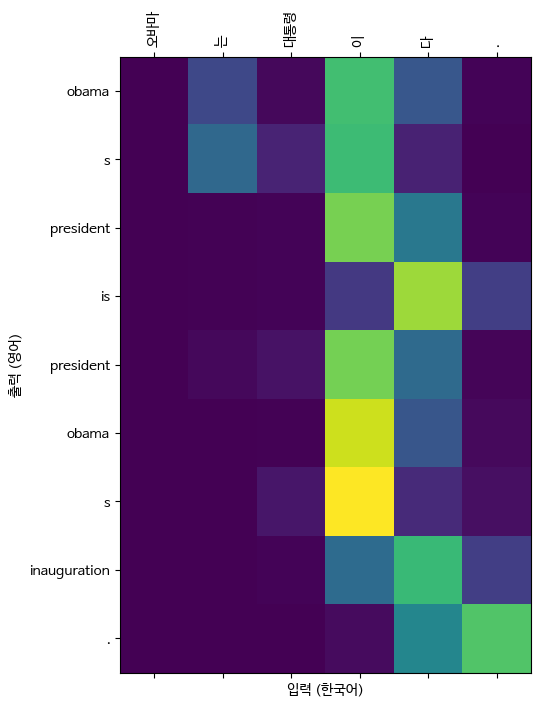

['obama',
 's',
 'president',
 'is',
 'president',
 'obama',
 's',
 'inauguration',
 '.']

In [53]:
# 과제 예문 4개
translate("오바마는 대통령이다.")

입력: 시민들은 도시 속에 산다.
번역: downtown city cities today in town , where dozens of people are known to have joined their lives .


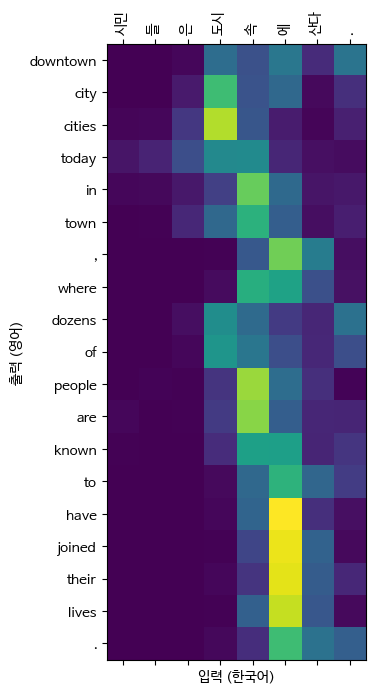

['downtown',
 'city',
 'cities',
 'today',
 'in',
 'town',
 ',',
 'where',
 'dozens',
 'of',
 'people',
 'are',
 'known',
 'to',
 'have',
 'joined',
 'their',
 'lives',
 '.']

In [54]:
translate("시민들은 도시 속에 산다.")

입력: 커피는 필요 없다.
번역: it s not much , but why needed necessary , simply <unk> it without much needed necessary .


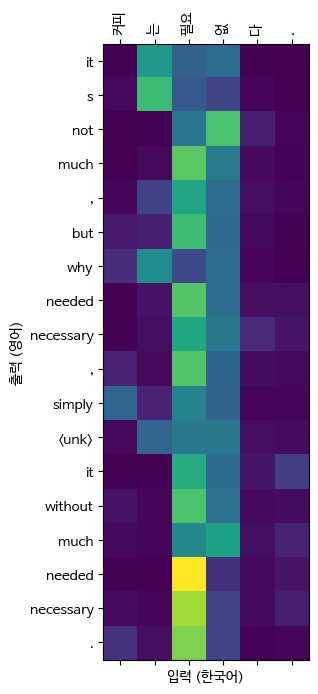

['it',
 's',
 'not',
 'much',
 ',',
 'but',
 'why',
 'needed',
 'necessary',
 ',',
 'simply',
 '<unk>',
 'it',
 'without',
 'much',
 'needed',
 'necessary',
 '.']

In [55]:
translate("커피는 필요 없다.")

입력: 일곱 명의 사망자가 발생했다.
번역: seven deaths were killed when the blast occurred across the country , killing seven people and death toll .


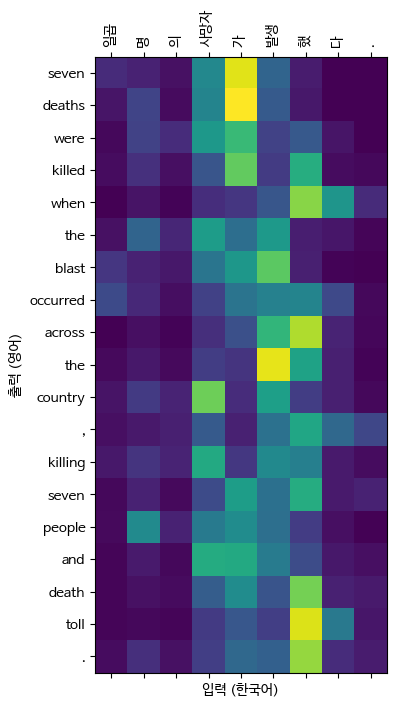

['seven',
 'deaths',
 'were',
 'killed',
 'when',
 'the',
 'blast',
 'occurred',
 'across',
 'the',
 'country',
 ',',
 'killing',
 'seven',
 'people',
 'and',
 'death',
 'toll',
 '.']

In [56]:
translate("일곱 명의 사망자가 발생했다.")

## Step 6. 환각(hallucination) 점검과 보완

번역 결과를 그냥 믿어도 될까? 초창기 챗지피티가 자신만만하게 틀린 말을 지어내던 것처럼,
이 작은 번역기도 **환각** 을 할 수 있겠다는 생각이 들었다. 그래서 출력을 점검하고 보완하는 과정을 넣어봤다.

### 왜 환각이 생기나
디코더는 **autoregressive** 라, 직전에 자기가 뱉은 단어를 다음 입력으로 받아 이어간다.
- 학습 때는 teacher forcing 으로 매 스텝 **정답** 단어를 먹였다 (Step 5 의 "한 칸 밀기").
- 추론 때는 정답이 없어 **자기 예측** 을 먹는다. 한 번 삐끗하면 틀린 걸 또 입력받아 눈덩이처럼 망가진다.
  이 학습-추론의 괴리를 **exposure bias** 라고 한다.

그 망가지는 모습이 환각이다. 작은 seq2seq 에서 전형적인 두 가지:
```
환각1 (반복)     : i don ' t don ' t don ' t ...   <- 같은 말 무한루프
환각2 (지어내기) : the united states president ...  <- 입력 무시, 그럴듯한 영어만
```

### 어떻게 점검·보완하나
1. **탐지** : 연속 반복 길이 / 반복 bigram / `<unk>` 수 / 미종료·길이비 를 보고 "환각 의심" 을 가린다.
2. **보완** : 디코딩 단계에서 `<unk>` 를 못 고르게 막고, 이미 쓴 단어에 페널티를 주고, 같은 bigram 반복을 금지한다.

In [57]:
# (1) 환각 탐지 - 번역 결과를 4가지 신호로 점검한다 (정답 없이도 "수상한지" 가린다)
def diagnose_translation(kor_tokens, eng_words):
    n = len(eng_words)
    # 연속 반복 최장 길이 (예: the the the -> 3). cur=지금 연속 길이, max_run=그 최댓값.
    #   "A if 조건 else B" = 삼항식(조건 참이면 A, 아니면 B). 결과가 있으면 (1,1)로, 비었으면 (0,0)으로 시작.
    max_run, cur = (1, 1) if n > 0 else (0, 0)
    for i in range(1, n):
        # 직전 단어와 같으면 연속 +1, 다르면 1로 리셋
        cur = cur + 1 if eng_words[i] == eng_words[i-1] else 1
        max_run = max(max_run, cur)
    # 반복된 bigram(연속 두 단어 쌍) 수 = 전체 쌍 개수 - 서로 다른 쌍 개수.
    #   set 은 중복을 없애므로, (전체 - 중복없는개수) = "중복으로 또 나온 쌍"의 개수.
    bigrams = [(eng_words[i], eng_words[i+1]) for i in range(n-1)]
    repeated_bigrams = len(bigrams) - len(set(bigrams))
    unk = eng_words.count("<unk>")                     # <unk>(모르는 단어) 개수
    not_ended = n >= MAX_LEN - 1                        # <end> 못 내고 끝까지 갔으면 의심
    len_ratio = round(n / max(1, len(kor_tokens)), 2)   # 입력 대비 출력이 너무 길면 의심 (max(1,..)=0나누기 방지)

    # 하나라도 비정상이면 "환각 의심" True (or = 하나라도 참이면 참)
    suspicious = (max_run >= 3) or (repeated_bigrams >= 2) or (unk > 0) or not_ended or (len_ratio > 3)
    return {"연속반복": max_run, "반복bigram": repeated_bigrams, "unk": unk,
            "미종료": not_ended, "길이비": len_ratio, "환각의심": suspicious}

In [58]:
# (2) 환각 억제 디코딩 - 재학습 없이, 추론할 때 다음 단어 점수(logits)를 손봐서 환각을 누른다
def generate_safe(sentence, max_len=MAX_LEN, block_unk=True, no_repeat_bigram=True, rep_penalty=1.3):
    model.eval()
    tokens = preprocess_korean(sentence)
    seq = kor_tokenizer.texts_to_sequences([tokens])[0]
    src = torch.tensor(seq, dtype=torch.long).unsqueeze(1).to(device)
    unk_id = eng_tokenizer.word_index.get("<unk>")

    generated, attentions = [], []
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src)            # 인코더로 입력 한 번 읽고
        # (캐싱 디코더 호환) enc(permute)와 proj_keys(W1 1회)를 루프 전에 미리 만든다
        enc = encoder_outputs.permute(1, 0, 2)                  # (batch, src_len, hidden) - bmm 용
        proj_keys = model.decoder.attention.W1(enc)             # W1 을 루프 밖에서 1회만 (캐싱 모델 규칙)
        inp = torch.tensor([bos_id], device=device)             # <start> 부터 시작
        for t in range(max_len):
            logits, hidden, attn = model.decoder(inp, hidden, enc, proj_keys)  # 다음 단어 점수(logits)
            logits = logits.squeeze(0)                          # (1,vocab) -> (vocab,) 단어마다 점수 하나

            # 안전장치 a: <unk>·pad 는 절대 못 고르게. 점수를 -무한대로 두면 argmax 가 절대 안 고른다.
            if block_unk and unk_id is not None:
                logits[unk_id] = -float("inf")
            logits[pad_id] = -float("inf")

            # 안전장치 b: 이미 쓴 단어는 점수를 깎아 반복 억제 (repetition penalty, rep_penalty=1.3 으로 나눔)
            #   점수가 양수면 나눠서 작게, 음수면 곱해서 더 작게 -> 어느 쪽이든 "덜 뽑히게" 만든다.
            for tok in set(generated):                          # set: 지금까지 쓴 단어들(중복 없이)
                logits[tok] = logits[tok] / rep_penalty if logits[tok] > 0 else logits[tok] * rep_penalty

            # 안전장치 c: "직전 단어 다음에 이미 한 번 나왔던 단어"는 금지 (같은 2단어 연속 = 반복 루프 차단)
            if no_repeat_bigram and generated:
                prev = generated[-1]                            # 직전에 생성한 단어
                for a, b in zip(generated, generated[1:]):      # 지금까지의 (앞,뒤) 단어쌍들을 훑어
                    if a == prev:                               # 앞단어가 직전단어와 같았던 적이 있으면
                        logits[b] = -float("inf")               # 그때 뒤따랐던 단어 b 를 금지(같은 쌍 반복 방지)

            top1 = int(logits.argmax())                         # 손본 점수에서 1등 단어
            attentions.append(attn.squeeze(0).cpu().numpy())
            if top1 == eos_id:                                  # <end> 면 종료
                break
            generated.append(top1)
            inp = torch.tensor([top1], device=device)           # 그 단어를 다음 스텝 입력으로

    words = [eng_tokenizer.index_word.get(i, "<unk>") for i in generated]
    return words, tokens, np.array(attentions[:len(words)]) if words else np.zeros((0, len(tokens)))

In [59]:
# (3) 기본 번역 vs 보완 번역 비교
def compare_translation(sentence):
    base_words, ktok, _ = evaluate(sentence)        # 기본 greedy
    safe_words, _, _ = generate_safe(sentence)       # 보완 디코딩
    diag = diagnose_translation(ktok, base_words)
    print("입력 :", sentence)
    print("기본 :", " ".join(base_words))
    print("점검 :", diag)
    print("보완 :", " ".join(safe_words))
    print("-" * 60)

for s in ["오바마는 대통령이다.", "시민들은 도시 속에 산다.",
          "커피는 필요 없다.", "일곱 명의 사망자가 발생했다."]:
    compare_translation(s)

입력 : 오바마는 대통령이다.
기본 : obama s president is president obama s inauguration .
점검 : {'연속반복': 1, '반복bigram': 1, 'unk': 0, '미종료': False, '길이비': 1.5, '환각의심': False}
보완 : obama s president is the president .
------------------------------------------------------------
입력 : 시민들은 도시 속에 산다.
기본 : downtown city cities today in town , where dozens of people are known to have joined their lives .
점검 : {'연속반복': 1, '반복bigram': 0, 'unk': 0, '미종료': False, '길이비': 2.38, '환각의심': False}
보완 : downtown city cities today in town , where dozens of people are known to have joined their lives .
------------------------------------------------------------
입력 : 커피는 필요 없다.
기본 : it s not much , but why needed necessary , simply <unk> it without much needed necessary .
점검 : {'연속반복': 1, '반복bigram': 1, 'unk': 1, '미종료': False, '길이비': 3.0, '환각의심': True}
보완 : it s not much , but why needed necessary if everybody needs to choose .
------------------------------------------------------------
입력 : 일곱 명의 사망자가 발생했다.
기본 : seven 

## Step 8. (예습) Transformer 로 바꿔 보기 — 이해는 다 못해도 적용·비교

> 마감이 다음날 오전 9시로 연기되었다. 그래서 2시간 정도만 더 투자해서, **예습 삼아** 아직 안 배운 **Transformer** 모델을 시도해본다.
> 솔직히 트랜스포머 내부 원리(self-attention 등)를 완전히 이해하고 짠 건 아니다. **공개된 표준 참고 코드를 가져와 적용**하고, 주석으로 짚어가며 **구버전(GRU seq2seq) 과 속도·번역 품질만 비교**해보는 게 목적이다.

**왜 Transformer 인가** : 앞 회고에 "번역 품질의 천장은 결국 Transformer + 더 많은 데이터"라고 적었다. 그 천장을 직접 만져보는 셈이다. RNN 을 아예 안 쓰고 **attention 만으로** 번역한다.

**처음 보는 개념 3개 (한 줄 요약)** :
- **self-attention** : 문장이 자기 자신을 본다. RNN 처럼 순서대로 한 단어씩 읽는 게 아니라, 모든 단어가 서로를 한 번에 참고한다 (병렬 처리라 빠를 수 있다).
- **positional encoding** : RNN 은 순서대로 읽어 순서가 공짜였는데, Transformer 는 한 번에 보니 "몇 번째 단어인지"를 따로 더해줘야 한다.
- **masking** : 디코더가 학습 때 정답의 "미래 단어"를 미리 훔쳐보지 못하게 가린다.

**참고(레퍼런스)** :
- PyTorch `nn.Transformer` 공식 문서 : https://docs.pytorch.org/docs/stable/generated/torch.nn.Transformer.html
- The Annotated Transformer (Harvard NLP) : https://nlp.seas.harvard.edu/annotated-transformer/
- 원논문 : Vaswani et al., "Attention Is All You Need" (2017), https://arxiv.org/abs/1706.03762

아래 코드는 위 `nn.Transformer` 표준 패턴을 가져와 우리 데이터(앞에서 만든 같은 토크나이저)에 맞춘 것이다.

In [22]:
# === (예습) Transformer 모델 정의 ===
# 참고: PyTorch nn.Transformer 문서 / The Annotated Transformer / "Attention Is All You Need"(2017)
# 핵심 층(self-attention 등)은 nn.Transformer 가 다 해주고, 우리는 4가지만 붙인다:
#   임베딩 / 위치인코딩 / 마스크 / 출력층.
import math

# (1) 위치 인코딩(Positional Encoding)
#  - RNN은 단어를 순서대로 읽어 "순서"가 공짜였지만, 트랜스포머는 문장을 한 번에(병렬) 보므로
#    "이 단어가 몇 번째인지"를 따로 만들어 더해줘야 한다. 그 순서표를 sin/cos로 만든다.
class PositionalEncoding(nn.Module):
    def __init__(self, emb_size, dropout=0.1, maxlen=5000):
        super().__init__()
        # den: 차원마다 다른 주파수(파장). 낮은 차원=느린 파동, 높은 차원=빠른 파동.
        den = torch.exp(-torch.arange(0, emb_size, 2) * math.log(10000) / emb_size)
        pos = torch.arange(0, maxlen).reshape(maxlen, 1)   # 위치 번호 0,1,2,...,maxlen-1
        pe = torch.zeros((maxlen, emb_size))               # (위치, 임베딩차원) 표
        pe[:, 0::2] = torch.sin(pos * den)                 # 짝수 차원 = sin
        pe[:, 1::2] = torch.cos(pos * den)                 # 홀수 차원 = cos
        self.dropout = nn.Dropout(dropout)
        # register_buffer: 학습하지 않는 고정값(가중치 아님)으로 모델에 저장. (len,1,emb) 모양
        self.register_buffer("pe", pe.unsqueeze(-2))
    def forward(self, token_emb):                          # token_emb: (문장길이, 배치, 임베딩)
        # 단어 임베딩에 그 위치의 순서표를 더해준다. [:size]로 문장 길이만큼만 잘라 씀.
        return self.dropout(token_emb + self.pe[:token_emb.size(0)])

# (2) 토큰 임베딩
#  - 단어 ID -> 벡터. 논문대로 sqrt(차원)을 곱해 위치인코딩과 크기(스케일)를 맞춘다.
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.emb_size = emb_size
    def forward(self, tokens):
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)

# (3) 인코더-디코더 Transformer 본체
class Seq2SeqTransformer(nn.Module):
    def __init__(self, num_enc, num_dec, emb_size, nhead, src_vocab, tgt_vocab, dim_ff=512, dropout=0.1):
        super().__init__()
        # nn.Transformer: 인코더층 num_enc개 + 디코더층 num_dec개. 내부에 멀티헤드 self-attention 다 들어있음.
        #  nhead=멀티헤드 개수(여러 관점으로 동시에 attention), dim_ff=각 층 내부 FFN 폭.
        self.transformer = nn.Transformer(d_model=emb_size, nhead=nhead,
            num_encoder_layers=num_enc, num_decoder_layers=num_dec,
            dim_feedforward=dim_ff, dropout=dropout)
        self.generator = nn.Linear(emb_size, tgt_vocab)        # 마지막: hidden -> 단어 점수(vocab)
        self.src_tok_emb = TokenEmbedding(src_vocab, emb_size) # 한국어(입력) 임베딩
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab, emb_size) # 영어(출력) 임베딩
        self.positional_encoding = PositionalEncoding(emb_size, dropout)
    def forward(self, src, trg, src_mask, tgt_mask, src_pad, tgt_pad, mem_pad):
        # 입력/출력 각각: 임베딩 -> 위치인코딩 더하기
        src_emb = self.positional_encoding(self.src_tok_emb(src))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))
        # 마스크 6종을 넣어 트랜스포머 한 번에 통과 (None=memory_mask는 안 씀)
        outs = self.transformer(src_emb, tgt_emb, src_mask, tgt_mask, None,
                                src_pad, tgt_pad, mem_pad)
        return self.generator(outs)                            # (문장길이, 배치, vocab)
    def encode(self, src, src_mask):                           # 추론용: 인코더만 돌려 memory 생성
        return self.transformer.encoder(self.positional_encoding(self.src_tok_emb(src)), src_mask)
    def decode(self, trg, memory, tgt_mask):                   # 추론용: 디코더만 (memory를 보며 한 단어씩)
        return self.transformer.decoder(self.positional_encoding(self.tgt_tok_emb(trg)), memory, tgt_mask)

# (4) 마스크 만들기 - 트랜스포머에서 제일 헷갈리는 부분
def generate_square_subsequent_mask(sz):
    # 디코더가 학습 때 "미래 단어"를 미리 훔쳐보지 못하게 가리는 삼각형 마스크.
    #  대각선 위(미래)는 -inf(=attention 0), 대각선 이하(과거·현재)는 0(=볼 수 있음).
    m = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    return m.float().masked_fill(m == 0, float("-inf")).masked_fill(m == 1, 0.0)

def create_mask(src, tgt):
    src_len, tgt_len = src.shape[0], tgt.shape[0]
    tgt_mask = generate_square_subsequent_mask(tgt_len)                         # 디코더: 미래 가리기
    src_mask = torch.zeros((src_len, src_len), device=device).type(torch.bool)  # 인코더: 다 봐도 됨(가림 없음)
    src_pad = (src == pad_id).transpose(0, 1)   # pad(0) 자리는 무시 -> True 표시, (배치,길이) 모양
    tgt_pad = (tgt == pad_id).transpose(0, 1)
    return src_mask, tgt_mask, src_pad, tgt_pad

# 모델 조립 (GRU와 공정 비교 위해 임베딩 차원은 256으로 동일. nhead=8 -> 256/8=32씩 8관점)
model_tf = Seq2SeqTransformer(num_enc=3, num_dec=3, emb_size=256, nhead=8,
                              src_vocab=kor_vocab_size, tgt_vocab=eng_vocab_size,
                              dim_ff=512, dropout=0.1).to(device)
for p in model_tf.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)   # 논문 권장 초기화(층 통과해도 신호 크기 유지)
print(model_tf)
print("파라미터 수:", sum(p.numel() for p in model_tf.parameters()))

Seq2SeqTransformer(
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): TransformerDecoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerDecoderLayer(
          (self_attn): MultiheadAttent

/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [23]:
# === (예습) Transformer 학습 (에폭별 체크포인트 저장 = 끊겨도 resume) ===
import time, os

BATCH_TF = 256
# Dataset/DataLoader는 GRU 때 만든 것 재사용 (teacher forcing용 trg_input/trg_label 한 칸 밀기 그대로)
loader_tf = DataLoader(TranslationDataset(kor_tensor, eng_tensor), batch_size=BATCH_TF, shuffle=True)
# 논문식 Adam(betas, eps). 트랜스포머는 lr에 민감해 일단 낮게(5e-4) 고정으로 둔다.
opt_tf = optim.Adam(model_tf.parameters(), lr=5e-4, betas=(0.9, 0.98), eps=1e-9)
EPOCHS_TF = 10

# 체크포인트는 산출물 아닌 작업파일이라 repo 밖(_scratch)에 저장
CKPT_TF = os.path.expanduser("~/Documents/AIFFEL_Work/_scratch/04_NLP/NLP01/verify/ckpt/transformer_b256.pt")
os.makedirs(os.path.dirname(CKPT_TF), exist_ok=True)
start_ep, hist_tf = 0, []
if os.path.exists(CKPT_TF):                          # 체크포인트 있으면 이어서(resume)
    ck = torch.load(CKPT_TF, map_location=device)
    model_tf.load_state_dict(ck["model_state"]); opt_tf.load_state_dict(ck["optimizer_state"])
    start_ep = ck["epoch"] + 1; hist_tf = ck["history"]
    print(f"체크포인트 발견 -> 에폭 {start_ep+1} 부터 이어서")
else:
    print("처음부터 학습 (Transformer)")

for epoch in range(start_ep, EPOCHS_TF):
    model_tf.train(); t0 = time.time(); tot = 0
    bar = tqdm(loader_tf, desc=f"TF Epoch {epoch+1}")
    for src, ti, tl in bar:
        # GRU 때와 똑같이 (배치,길이) -> (길이,배치)로 축 변환
        src = src.permute(1, 0).to(device); ti = ti.permute(1, 0).to(device); tl = tl.permute(1, 0).to(device)
        sm, tm, sp, tp = create_mask(src, ti)          # 마스크 4종 생성(미래가리기+pad무시)
        logits = model_tf(src, ti, sm, tm, sp, tp, sp) # 마지막 인자(mem_pad)=src_pad
        opt_tf.zero_grad()                             # 지난 기울기 청소
        loss = criterion(logits.reshape(-1, logits.shape[-1]), tl.reshape(-1))  # 단어 하나당 한 줄로 펼쳐 CE
        loss.backward()                                # 역전파(기울기 계산)
        torch.nn.utils.clip_grad_norm_(model_tf.parameters(), 1.0)  # 기울기 폭주 방지(안전벨트)
        opt_tf.step(); tot += loss.item(); bar.set_postfix(loss=loss.item())   # 한 발짝 업데이트
    dt = time.time() - t0; avg = tot / len(loader_tf)
    hist_tf.append({"epoch": epoch + 1, "loss": round(avg, 4), "min": round(dt / 60, 1)})
    # 매 에폭 끝마다 체크포인트 저장 -> 끊기거나 더 돌리고 싶을 때 이어감
    torch.save({"epoch": epoch, "model_state": model_tf.state_dict(),
                "optimizer_state": opt_tf.state_dict(), "history": hist_tf}, CKPT_TF)
    print(f"TF Epoch {epoch+1}/{EPOCHS_TF}  loss={avg:.4f}  ({dt/60:.1f}분)")
print("\nTransformer 학습 끝:", hist_tf)

처음부터 학습 (Transformer)


TF Epoch 1:   0%|          | 0/239 [00:00<?, ?it/s]/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/torch/nn/functional.py:6487: UserWarning: Mem Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:360.)
  attn_output = scaled_dot_product_attention(
/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
TF Epoch 1: 100%|██████████| 239/239 [01:21<00:00,  2.92it/s, loss=5.67]


TF Epoch 1/10  loss=6.3521  (1.4분)


TF Epoch 2: 100%|██████████| 239/239 [01:21<00:00,  2.95it/s, loss=5]   


TF Epoch 2/10  loss=5.2278  (1.4분)


...

TF Epoch 8/10  loss=3.3023  (1.4분)


TF Epoch 9: 100%|██████████| 239/239 [01:21<00:00,  2.95it/s, loss=3.1] 


TF Epoch 9/10  loss=3.0920  (1.4분)


TF Epoch 10: 100%|██████████| 239/239 [01:20<00:00,  2.95it/s, loss=2.92]


TF Epoch 10/10  loss=2.9005  (1.3분)

Transformer 학습 끝: [{'epoch': 1, 'loss': 6.3521, 'min': 1.4}, {'epoch': 2, 'loss': 5.2278, 'min': 1.4}, {'epoch': 3, 'loss': 4.7419, 'min': 1.4}, {'epoch': 4, 'loss': 4.3819, 'min': 1.4}, {'epoch': 5, 'loss': 4.065, 'min': 1.4}, {'epoch': 6, 'loss': 3.786, 'min': 1.4}, {'epoch': 7, 'loss': 3.5304, 'min': 1.4}, {'epoch': 8, 'loss': 3.3023, 'min': 1.4}, {'epoch': 9, 'loss': 3.092, 'min': 1.4}, {'epoch': 10, 'loss': 2.9005, 'min': 1.3}]


In [25]:
# === (예습) Transformer 번역 + 구버전(GRU) 과 비교 ===
@torch.no_grad()                                    # 추론이라 기울기 계산 끔(빠르고 메모리 절약)
def translate_transformer(sentence, max_len=MAX_LEN):
    model_tf.eval()                                 # 평가 모드(dropout 끔)
    tokens = preprocess_korean(sentence)            # 한국어 -> 형태소 토큰
    seq = kor_tokenizer.texts_to_sequences([tokens])[0]   # 토큰 -> 번호
    src = torch.tensor(seq, dtype=torch.long).reshape(-1, 1).to(device)  # (길이, 1)
    src_mask = torch.zeros((src.shape[0], src.shape[0]), device=device).type(torch.bool)
    memory = model_tf.encode(src, src_mask)         # 인코더 한 번 -> memory(입력을 요약한 표현)
    ys = torch.tensor([[bos_id]], device=device)    # <start>부터 시작
    for _ in range(max_len):                        # 한 단어씩 autoregressive 생성
        tgt_mask = generate_square_subsequent_mask(ys.shape[0])   # 지금까지 생성분에 대한 미래가리기
        out = model_tf.decode(ys, memory, tgt_mask) # 디코더: memory 보며 다음 hidden
        prob = model_tf.generator(out[-1])          # 마지막 위치의 다음 단어 점수
        nxt = int(prob.argmax(-1))                  # greedy: 1등 단어
        if nxt == eos_id:                           # <end> 나오면 종료
            break
        ys = torch.cat([ys, torch.tensor([[nxt]], device=device)], dim=0)   # 생성 단어를 뒤에 붙임
    idxs = ys.squeeze(1).tolist()[1:]               # 맨 앞 <start> 빼고 번호 리스트
    return [eng_tokenizer.index_word.get(i, "<unk>") for i in idxs]         # 번호 -> 단어

print("구버전(GRU seq2seq + attention)  vs  예습(Transformer)  번역 비교")
print("=" * 64)
for s in ["오바마는 대통령이다.", "시민들은 도시 속에 산다.", "커피는 필요 없다.", "일곱 명의 사망자가 발생했다."]:
    gru_words, _, _ = evaluate(s)                   # 구버전(GRU) greedy 번역
    tf_words = translate_transformer(s)             # Transformer greedy 번역
    print("입력        :", s)
    print("GRU         :", " ".join(gru_words))
    print("Transformer :", " ".join(tf_words))
    print("-" * 64)

구버전(GRU seq2seq + attention)  vs  예습(Transformer)  번역 비교
입력        : 오바마는 대통령이다.
GRU         : obama s president is president obama s saved .
Transformer : obama is the president .
----------------------------------------------------------------


/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/torch/nn/functional.py:6487: UserWarning: Flash Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:309.)
  attn_output = scaled_dot_product_attention(


입력        : 시민들은 도시 속에 산다.
GRU         : more people were fighter with and at home market draw a baby at the low .
Transformer : citizens are <unk> in the city .
----------------------------------------------------------------
입력        : 커피는 필요 없다.
GRU         : shortages significantly , or not experience of significantly 5 don t have much needed to gen it 5
Transformer : coffee is not going to be able to get out of coffee .
----------------------------------------------------------------
입력        : 일곱 명의 사망자가 발생했다.
GRU         : having from death quarter died when the overseas was killed , but others died in the sign .
Transformer : seven people were killed .
----------------------------------------------------------------


### (공부 메모) 왜 Transformer 가 GRU 보다 학습이 빠른가 — 병렬성

| 모델 | 에폭당 시간 | 문장 읽는 방식 |
|------|------------|----------------|
| GRU seq2seq | 약 5.3분 | 단어를 1번 -> 2번 -> 3번 순서대로 (직렬) |
| Transformer | 약 1.4분 | 문장의 모든 단어를 한 번에 (병렬) |

- **GRU(RNN)** 는 t 번째 계산에 t-1 번째 결과(hidden state)가 꼭 필요하다. 그래서 순서대로만 처리할 수 있어 GPU 병렬 연산을 못 살린다.
- **Transformer** 는 self-attention 으로 모든 위치를 동시에 계산한다. 순서 의존이 없어 GPU 를 꽉 채우니, 더 큰 모델(3+3층)인데도 더 빨랐다.
- 단, 빠르다고 에폭당 품질이 더 좋진 않았다 : 초반 loss 는 GRU 보다 천천히 떨어졌다 (TF 에폭10 loss 2.90 vs GRU 에폭10 1.19). 대신 에폭이 싸니(1.4분) 에폭을 더 돌려 보완할 수 있어, 10에폭과 20에폭을 따로 비교해봤다.

> 정리 : Transformer 의 큰 실용적 장점 하나가 "순서 의존을 없애 병렬 학습이 가능"하다는 것. RNN 의 직렬 한계를 푼 셈이고, 그래서 요즘 대형 언어모델이 다 Transformer 기반이다.

In [26]:
# === (예습) Transformer 학습 (에폭별 체크포인트 저장 = 끊겨도 resume) ===
import time, os

BATCH_TF = 256
loader_tf = DataLoader(TranslationDataset(kor_tensor, eng_tensor), batch_size=BATCH_TF, shuffle=True)
# 논문식 Adam 설정 (betas, eps). Transformer 는 lr 에 민감해 좀 낮게 둔다.
opt_tf = optim.Adam(model_tf.parameters(), lr=5e-4, betas=(0.9, 0.98), eps=1e-9)
EPOCHS_TF = 20   # 20으로 올려봄

CKPT_TF = os.path.expanduser("~/Documents/AIFFEL_Work/_scratch/04_NLP/NLP01/verify/ckpt/transformer_b256.pt")
os.makedirs(os.path.dirname(CKPT_TF), exist_ok=True)
start_ep, hist_tf = 0, []
if os.path.exists(CKPT_TF):
    ck = torch.load(CKPT_TF, map_location=device)
    model_tf.load_state_dict(ck["model_state"]); opt_tf.load_state_dict(ck["optimizer_state"])
    start_ep = ck["epoch"] + 1; hist_tf = ck["history"]
    print(f"체크포인트 발견 -> 에폭 {start_ep+1} 부터 이어서")
else:
    print("처음부터 학습 (Transformer)")

for epoch in range(start_ep, EPOCHS_TF):
    model_tf.train(); t0 = time.time(); tot = 0
    bar = tqdm(loader_tf, desc=f"TF Epoch {epoch+1}")
    for src, ti, tl in bar:
        # GRU 때와 똑같이 (배치,길이) -> (길이,배치) 로 돌린다
        src = src.permute(1, 0).to(device); ti = ti.permute(1, 0).to(device); tl = tl.permute(1, 0).to(device)
        sm, tm, sp, tp = create_mask(src, ti)              # 마스크 만들기
        logits = model_tf(src, ti, sm, tm, sp, tp, sp)     # mem_pad 는 src_pad 와 같다
        opt_tf.zero_grad()
        loss = criterion(logits.reshape(-1, logits.shape[-1]), tl.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_tf.parameters(), 1.0)
        opt_tf.step(); tot += loss.item(); bar.set_postfix(loss=loss.item())
    dt = time.time() - t0; avg = tot / len(loader_tf)
    hist_tf.append({"epoch": epoch + 1, "loss": round(avg, 4), "min": round(dt / 60, 1)})
    torch.save({"epoch": epoch, "model_state": model_tf.state_dict(),
                "optimizer_state": opt_tf.state_dict(), "history": hist_tf}, CKPT_TF)
    print(f"TF Epoch {epoch+1}/{EPOCHS_TF}  loss={avg:.4f}  ({dt/60:.1f}분)")
print("\nTransformer 학습 끝:", hist_tf)

체크포인트 발견 -> 에폭 11 부터 이어서


TF Epoch 11: 100%|██████████| 239/239 [01:21<00:00,  2.93it/s, loss=2.84]


TF Epoch 11/20  loss=2.7250  (1.4분)


TF Epoch 12: 100%|██████████| 239/239 [01:21<00:00,  2.93it/s, loss=2.56]


TF Epoch 12/20  loss=2.5654  (1.4분)


...

TF Epoch 18/20  loss=1.8372  (1.4분)


TF Epoch 19: 100%|██████████| 239/239 [01:21<00:00,  2.93it/s, loss=1.85]


TF Epoch 19/20  loss=1.7462  (1.4분)


TF Epoch 20: 100%|██████████| 239/239 [01:22<00:00,  2.91it/s, loss=1.76]


TF Epoch 20/20  loss=1.6623  (1.4분)

Transformer 학습 끝: [{'epoch': 1, 'loss': 6.3521, 'min': 1.4}, {'epoch': 2, 'loss': 5.2278, 'min': 1.4}, {'epoch': 3, 'loss': 4.7419, 'min': 1.4}, {'epoch': 4, 'loss': 4.3819, 'min': 1.4}, {'epoch': 5, 'loss': 4.065, 'min': 1.4}, {'epoch': 6, 'loss': 3.786, 'min': 1.4}, {'epoch': 7, 'loss': 3.5304, 'min': 1.4}, {'epoch': 8, 'loss': 3.3023, 'min': 1.4}, {'epoch': 9, 'loss': 3.092, 'min': 1.4}, {'epoch': 10, 'loss': 2.9005, 'min': 1.3}, {'epoch': 11, 'loss': 2.725, 'min': 1.4}, {'epoch': 12, 'loss': 2.5654, 'min': 1.4}, {'epoch': 13, 'loss': 2.4183, 'min': 1.4}, {'epoch': 14, 'loss': 2.2816, 'min': 1.4}, {'epoch': 15, 'loss': 2.1551, 'min': 1.4}, {'epoch': 16, 'loss': 2.0392, 'min': 1.4}, {'epoch': 17, 'loss': 1.9337, 'min': 1.4}, {'epoch': 18, 'loss': 1.8372, 'min': 1.4}, {'epoch': 19, 'loss': 1.7462, 'min': 1.4}, {'epoch': 20, 'loss': 1.6623, 'min': 1.4}]


In [27]:
# === (예습) Transformer 번역 + 구버전(GRU) 과 비교 2 : 20번 에폭까지 실행 후 재실행하는 동일한 코드 ===
@torch.no_grad()
def translate_transformer(sentence, max_len=MAX_LEN):
    model_tf.eval()
    tokens = preprocess_korean(sentence)
    seq = kor_tokenizer.texts_to_sequences([tokens])[0]
    src = torch.tensor(seq, dtype=torch.long).reshape(-1, 1).to(device)          # (len, 1)
    src_mask = torch.zeros((src.shape[0], src.shape[0]), device=device).type(torch.bool)
    memory = model_tf.encode(src, src_mask)                                       # 인코더 한 번
    ys = torch.tensor([[bos_id]], device=device)                                 # <start> 부터
    for _ in range(max_len):
        tgt_mask = generate_square_subsequent_mask(ys.shape[0])
        out = model_tf.decode(ys, memory, tgt_mask)
        prob = model_tf.generator(out[-1])      # 마지막 위치의 다음 단어 점수
        nxt = int(prob.argmax(-1))              # greedy (1등 고르기)
        if nxt == eos_id:
            break
        ys = torch.cat([ys, torch.tensor([[nxt]], device=device)], dim=0)
    idxs = ys.squeeze(1).tolist()[1:]           # 맨 앞 <start> 제외
    return [eng_tokenizer.index_word.get(i, "<unk>") for i in idxs]

print("구버전(GRU seq2seq + attention)  vs  예습(Transformer)  번역 비교")
print("=" * 64)
for s in ["오바마는 대통령이다.", "시민들은 도시 속에 산다.", "커피는 필요 없다.", "일곱 명의 사망자가 발생했다."]:
    gru_words, _, _ = evaluate(s)               # 구버전 (greedy)
    tf_words = translate_transformer(s)         # Transformer (greedy)
    print("입력        :", s)
    print("GRU         :", " ".join(gru_words))
    print("Transformer :", " ".join(tf_words))
    print("-" * 64)

구버전(GRU seq2seq + attention)  vs  예습(Transformer)  번역 비교
입력        : 오바마는 대통령이다.
GRU         : obama s president is president obama s saved .
Transformer : obama is the president elect .
----------------------------------------------------------------
입력        : 시민들은 도시 속에 산다.
GRU         : more people were fighter with and at home market draw a baby at the low .
Transformer : citizens in the city of <unk> .
----------------------------------------------------------------
입력        : 커피는 필요 없다.
GRU         : shortages significantly , or not experience of significantly 5 don t have much needed to gen it 5
Transformer : coffee has a tough approach .
----------------------------------------------------------------
입력        : 일곱 명의 사망자가 발생했다.
GRU         : having from death quarter died when the overseas was killed , but others died in the sign .
Transformer : seven deaths were reported .
----------------------------------------------------------------


### (예습) lr warmup — 트랜스포머의 정답 처방 시도

앞 트랜스포머는 고정 lr 5e-4 라 20에폭에야 loss 1.66 이었다 (GRU 는 10에폭에 1.19). 트랜스포머가 잘 안 풀린 큰 이유가 **lr 스케줄**이라, 표준 방법인 **warmup** 을 시도한다.

**lr warmup 이란** : 학습 초반 lr 을 0 부터 천천히 올렸다가(warmup), 그 뒤 서서히 줄이는 방식.
- **왜 올렸다 내리나** : 초반엔 모델이 엉망이라 큰 걸음(높은 lr)을 디디면 휘청인다 -> 작게 시작해 워밍업하고, 자리잡으면 lr 을 키워 빨리 배우고, 후반엔 줄여 안정적으로 수렴.
- 원논문의 **Noam 스케줄** : `lr = d_model^-0.5 * min(step^-0.5, step * warmup^-1.5)`. warmup 스텝까지 직선으로 오르고, 그 뒤 1/√step 으로 내림.
- 우리 설정(d_model=256, warmup=500) : lr 0 -> 약 0.0028(피크, 약 2에폭) -> 감소. 고정 5e-4 보다 피크가 높아 더 빨리 배울 것으로 기대.

아래는 새 모델(model_tf_warm)을 warmup 으로 처음부터 학습해 고정 lr 판과 비교한다.

In [49]:
# === (예습) Transformer + lr warmup(Noam) 으로 새로 학습 ===
import time, os
# 고정 lr 판(model_tf)과 따로 비교하려고 새 모델 model_tf_warm 을 만든다 (둘 다 메모리에 둬서 3종 비교)
model_tf_warm = Seq2SeqTransformer(num_enc=3, num_dec=3, emb_size=256, nhead=8,
                                   src_vocab=kor_vocab_size, tgt_vocab=eng_vocab_size,
                                   dim_ff=512, dropout=0.1).to(device)
for p in model_tf_warm.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)

loader_tf = DataLoader(TranslationDataset(kor_tensor, eng_tensor), batch_size=256, shuffle=True)
# ★ base lr=1.0 으로 두고, 스케줄러가 매 스텝 진짜 lr 을 만든다(아래 noam_lr 곱해짐)
opt_warm = optim.Adam(model_tf_warm.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

D_MODEL, WARMUP = 256, 500
def noam_lr(step):
    # Noam 스케줄: warmup 스텝까지는 직선으로 lr 올리고(준비운동), 그 뒤 1/sqrt(step)로 줄인다.
    #  step^-0.5  와  step*warmup^-1.5  중 작은 값 -> 초반엔 두번째(상승), 이후 첫번째(하강)가 이김.
    step = max(step, 1)
    return (D_MODEL ** -0.5) * min(step ** -0.5, step * WARMUP ** -1.5)
scheduler = torch.optim.lr_scheduler.LambdaLR(opt_warm, lr_lambda=noam_lr)   # 실제 lr = 1.0 * noam_lr(step)

EPOCHS_WARM = 20
CKPT_W = os.path.expanduser("~/Documents/AIFFEL_Work/_scratch/04_NLP/NLP01/verify/ckpt/transformer_warmup.pt")
os.makedirs(os.path.dirname(CKPT_W), exist_ok=True)
start_ep, hist_w = 0, []
if os.path.exists(CKPT_W):
    ck = torch.load(CKPT_W, map_location=device)
    model_tf_warm.load_state_dict(ck["model_state"]); opt_warm.load_state_dict(ck["optimizer_state"])
    scheduler.load_state_dict(ck["scheduler_state"]); start_ep = ck["epoch"] + 1; hist_w = ck["history"]
    print(f"체크포인트 발견 -> 에폭 {start_ep+1} 부터")
else:
    print("처음부터 학습 (Transformer + warmup)")

for epoch in range(start_ep, EPOCHS_WARM):
    model_tf_warm.train(); t0 = time.time(); tot = 0
    bar = tqdm(loader_tf, desc=f"warmup Epoch {epoch+1}")
    for src, ti, tl in bar:
        src = src.permute(1, 0).to(device); ti = ti.permute(1, 0).to(device); tl = tl.permute(1, 0).to(device)
        sm, tm, sp, tp = create_mask(src, ti)
        logits = model_tf_warm(src, ti, sm, tm, sp, tp, sp)
        opt_warm.zero_grad()
        loss = criterion(logits.reshape(-1, logits.shape[-1]), tl.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_tf_warm.parameters(), 1.0)
        opt_warm.step(); scheduler.step()            # ★ step()으로 한 발짝, scheduler.step()으로 lr 갱신(매 배치)
        tot += loss.item(); bar.set_postfix(loss=loss.item(), lr=opt_warm.param_groups[0]["lr"])
    dt = time.time() - t0; avg = tot / len(loader_tf)
    hist_w.append({"epoch": epoch + 1, "loss": round(avg, 4), "lr": round(opt_warm.param_groups[0]["lr"], 6), "min": round(dt / 60, 1)})
    torch.save({"epoch": epoch, "model_state": model_tf_warm.state_dict(),
                "optimizer_state": opt_warm.state_dict(), "scheduler_state": scheduler.state_dict(),
                "history": hist_w}, CKPT_W)
    print(f"warmup Epoch {epoch+1}/{EPOCHS_WARM}  loss={avg:.4f}  lr={opt_warm.param_groups[0]['lr']:.5f}  ({dt/60:.1f}분)")
print("\n끝:", hist_w)

처음부터 학습 (Transformer + warmup)


warmup Epoch 1: 100%|██████████| 239/239 [01:21<00:00,  2.95it/s, loss=5.46, lr=0.00134] 


warmup Epoch 1/20  loss=6.8752  lr=0.00134  (1.4분)


warmup Epoch 2: 100%|██████████| 239/239 [01:21<00:00,  2.95it/s, loss=4.61, lr=0.00267]


warmup Epoch 2/20  loss=5.0192  lr=0.00267  (1.4분)


...

warmup Epoch 18/20  loss=1.4177  lr=0.00095  (1.4분)


warmup Epoch 19: 100%|██████████| 239/239 [01:21<00:00,  2.95it/s, loss=1.49, lr=0.000927]


warmup Epoch 19/20  loss=1.3583  lr=0.00093  (1.4분)


warmup Epoch 20: 100%|██████████| 239/239 [01:21<00:00,  2.95it/s, loss=1.43, lr=0.000904]


warmup Epoch 20/20  loss=1.3036  lr=0.00090  (1.4분)

끝: [{'epoch': 1, 'loss': 6.8752, 'lr': 0.001336, 'min': 1.4}, {'epoch': 2, 'loss': 5.0192, 'lr': 0.002672, 'min': 1.4}, {'epoch': 3, 'loss': 4.3922, 'lr': 0.002334, 'min': 1.4}, {'epoch': 4, 'loss': 3.8578, 'lr': 0.002021, 'min': 1.4}, {'epoch': 5, 'loss': 3.4356, 'lr': 0.001808, 'min': 1.4}, {'epoch': 6, 'loss': 3.0955, 'lr': 0.00165, 'min': 1.4}, {'epoch': 7, 'loss': 2.812, 'lr': 0.001528, 'min': 1.4}, {'epoch': 8, 'loss': 2.5783, 'lr': 0.001429, 'min': 1.4}, {'epoch': 9, 'loss': 2.3801, 'lr': 0.001348, 'min': 1.4}, {'epoch': 10, 'loss': 2.2122, 'lr': 0.001278, 'min': 1.4}, {'epoch': 11, 'loss': 2.0654, 'lr': 0.001219, 'min': 1.4}, {'epoch': 12, 'loss': 1.9363, 'lr': 0.001167, 'min': 1.4}, {'epoch': 13, 'loss': 1.8246, 'lr': 0.001121, 'min': 1.4}, {'epoch': 14, 'loss': 1.725, 'lr': 0.00108, 'min': 1.4}, {'epoch': 15, 'loss': 1.636, 'lr': 0.001044, 'min': 1.3}, {'epoch': 16, 'loss': 1.5558, 'lr': 0.001011, 'min': 1.4}, {'epoch': 17,

In [50]:
# === (예습) 3종 비교 : GRU vs Transformer(고정 lr) vs Transformer(warmup) ===
@torch.no_grad()
def tf_translate(m, sentence, max_len=MAX_LEN):     # 어떤 트랜스포머 모델(m)이든 받아 번역(고정/warmup 둘 다 씀)
    m.eval()
    tokens = preprocess_korean(sentence)
    seq = kor_tokenizer.texts_to_sequences([tokens])[0]
    src = torch.tensor(seq, dtype=torch.long).reshape(-1, 1).to(device)
    sm = torch.zeros((src.shape[0], src.shape[0]), device=device).type(torch.bool)
    memory = m.encode(src, sm)                       # 인코더 한 번
    ys = torch.tensor([[bos_id]], device=device)
    for _ in range(max_len):                         # 한 단어씩 greedy 생성
        out = m.decode(ys, memory, generate_square_subsequent_mask(ys.shape[0]))
        nxt = int(m.generator(out[-1]).argmax(-1))
        if nxt == eos_id:
            break
        ys = torch.cat([ys, torch.tensor([[nxt]], device=device)], dim=0)
    return [eng_tokenizer.index_word.get(i, "<unk>") for i in ys.squeeze(1).tolist()[1:]]

print("GRU  vs  Transformer(고정 lr)  vs  Transformer(warmup)")
print("=" * 66)
for s in ["오바마는 대통령이다.", "시민들은 도시 속에 산다.", "커피는 필요 없다.", "일곱 명의 사망자가 발생했다."]:
    g, _, _ = evaluate(s)                            # GRU
    print("입력         :", s)
    print("GRU          :", " ".join(g))
    print("TF (고정 lr) :", " ".join(tf_translate(model_tf, s)))      # 고정 lr 트랜스포머
    print("TF (warmup)  :", " ".join(tf_translate(model_tf_warm, s))) # warmup 트랜스포머
    print("-" * 66)

GRU  vs  Transformer(고정 lr)  vs  Transformer(warmup)
입력         : 오바마는 대통령이다.
GRU          : obama s president is president obama s saved .
TF (고정 lr) : obama is the president elect .
TF (warmup)  : obama is a quick !
------------------------------------------------------------------
입력         : 시민들은 도시 속에 산다.
GRU          : more people were fighter with and at home market draw a baby at the low .
TF (고정 lr) : citizens in the city of <unk> .
TF (warmup)  : citizens in the city have been <unk> in the <unk> neighborhood
------------------------------------------------------------------
입력         : 커피는 필요 없다.
GRU          : shortages significantly , or not experience of significantly 5 don t have much needed to gen it 5
TF (고정 lr) : coffee has a tough approach .
TF (warmup)  : coffee
------------------------------------------------------------------
입력         : 일곱 명의 사망자가 발생했다.
GRU          : having from death quarter died when the overseas was killed , but others died in the sign .
TF

In [54]:
# === (예습) BLEU 정량 평가 — GRU vs TF(고정) vs TF(warmup) ===
# BLEU: 모델 번역과 정답이 겹치는 단어 덩어리(1~4-gram) 비율 + 너무 짧으면 감점. 0~100, 높을수록 좋음.
# 주의: 검증셋을 따로 안 나눠서 학습에 쓴 데이터에서 뽑아 잰다(train-set BLEU).
#       절대값은 낙관적이지만, 세 모델을 "같은 문장"으로 재니 상대 비교엔 쓸 수 있다.
import random
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tqdm import tqdm
smooth = SmoothingFunction().method4               # 짧은 문장에서 0점 방지용 보정

random.seed(42)                                    # 매번 같은 표본 뽑게 고정(재현성)
N = min(300, len(kor_corpus))
sample_idx = random.sample(range(len(kor_corpus)), N)
SPECIAL = {"<start>", "<end>", "<pad>"}
# refs: 문장마다 [정답토큰리스트] (참조 여러 개 가능해서 한 겹 더 감쌈). eng_corpus가 정답.
refs = [[[w for w in eng_corpus[i] if w not in SPECIAL]] for i in sample_idx]

@torch.no_grad()
def gru_from_tokens(tokens):                        # 이미 토큰화된 한국어 토큰으로 바로 번역(전처리 생략)
    model.eval()
    seq = kor_tokenizer.texts_to_sequences([tokens])[0]
    src = torch.tensor(seq, dtype=torch.long).unsqueeze(1).to(device)
    outputs, _ = model(src, max_len=MAX_LEN, bos_id=bos_id, eos_id=eos_id)
    out = []
    for idx in outputs.argmax(2).squeeze(1).tolist():
        w = eng_tokenizer.index_word.get(idx, "<unk>")
        if w == "<end>": break
        out.append(w)
    return out

@torch.no_grad()
def tf_from_tokens(m, tokens):                       # 트랜스포머용(고정/warmup 공용), 토큰으로 바로 번역
    m.eval()
    seq = kor_tokenizer.texts_to_sequences([tokens])[0]
    src = torch.tensor(seq, dtype=torch.long).reshape(-1, 1).to(device)
    sm = torch.zeros((src.shape[0], src.shape[0]), device=device).type(torch.bool)
    memory = m.encode(src, sm)
    ys = torch.tensor([[bos_id]], device=device)
    for _ in range(MAX_LEN):
        nxt = int(m.generator(m.decode(ys, memory, generate_square_subsequent_mask(ys.shape[0]))[-1]).argmax(-1))
        if nxt == eos_id: break
        ys = torch.cat([ys, torch.tensor([[nxt]], device=device)], dim=0)
    return [eng_tokenizer.index_word.get(i, "<unk>") for i in ys.squeeze(1).tolist()[1:]]

print(f"{N}개 문장으로 BLEU 측정 (모델당 {N}문장 번역)")
bleus = {}
# 세 모델 각각 N문장 번역 -> corpus_bleu(전체 참조, 전체 가설)로 한 점수
hyps = [gru_from_tokens(kor_corpus[i]) for i in tqdm(sample_idx, desc="GRU")]
bleus["GRU"] = corpus_bleu(refs, hyps, smoothing_function=smooth) * 100
hyps = [tf_from_tokens(model_tf, kor_corpus[i]) for i in tqdm(sample_idx, desc="TF고정")]
bleus["TF(고정lr)"] = corpus_bleu(refs, hyps, smoothing_function=smooth) * 100
hyps = [tf_from_tokens(model_tf_warm, kor_corpus[i]) for i in tqdm(sample_idx, desc="TFwarmup")]
bleus["TF(warmup)"] = corpus_bleu(refs, hyps, smoothing_function=smooth) * 100

print("\n=== BLEU (train-set, 비교용 / 높을수록 좋음) ===")
for k, v in bleus.items():
    print(f"  {k:12s}: {v:.2f}")

300개 문장으로 BLEU 측정 (모델당 300문장 번역)


TFwarmup: 100%|██████████| 300/300 [01:27<00:00,  3.42it/s]


=== BLEU (train-set, 비교용 / 높을수록 좋음) ===
  GRU         : 1.16
  TF(고정lr)    : 31.45
  TF(warmup)  : 34.89


### (예습) BLEU 정량 평가 결과 — 눈대중을 숫자로

| 모델 | 최종 loss | BLEU (train-set, 300문장) |
|------|----------|---------------------------|
| GRU seq2seq+attention | 1.19 (최저) | **1.16** (거의 0) |
| Transformer (고정 lr) | 1.66 | 31.45 |
| Transformer (warmup) | 1.30 | **34.89** (최고) |

- **구조 전환(GRU→Transformer)이 압도적 레버였다** : BLEU 1.16 → 31~35 (약 30배). GRU를 아무리 튜닝해도 이 격차는 못 메운다. 트랜스포머로 바꾼 게 옳은 선택이었음을 숫자가 확인해줬다.
- **warmup이 BLEU에서도 고정 lr을 앞섰다 (34.89 > 31.45)** : 앞의 예문 4개 눈대중으론 warmup이 더 별로처럼 보였는데(`coffee`, `obama is a quick`), 300문장으로 재니 오히려 더 좋았다. **눈대중과 정량 지표가 어긋날 수 있어, BLEU 같은 지표가 필요하다**는 걸 직접 겪었다.
- **loss와 품질은 또 따로** : GRU는 loss 최저(1.19)인데 BLEU 최저(1.16). loss가 낮다고 번역이 좋은 게 아니다 — 이번엔 정량으로 못박았다.
- 한계 : 검증셋 미분리(train-set BLEU)라 절대값은 낙관적. 엄밀한 평가는 held-out + BLEU가 다음 과제.

> BLEU = 모델 번역과 정답이 겹치는 단어 덩어리(1~4-gram) 비율 + 짧으면 감점. 0~100, 높을수록 좋음.

## (추가 조사) scheduled sampling — exposure bias 를 "학습 단계"에서 줄이는 법

> 이건 이 노트북에서 직접 돌려본 게 아니라, exposure bias 를 더 알아보다가 **조사만 한 내용**이다(다음에 시도할 것). 맥락상 여기 적어둔다.

**문제 복습** : teacher forcing 은 학습 때 늘 *정답* 단어를 떠먹여서, 모델이 "자기 예측을 입력으로 받는 상황"(추론 환경)을 연습하지 못한다 -> exposure bias.

**scheduled sampling 의 아이디어** : 학습 중에 **가끔 정답 대신 모델 자신의 예측을 입력으로 넣는다.** 그 비율을 처음엔 낮게, 에폭이 갈수록 높인다(그래서 "scheduled" = 정해진 일정으로 비율 변화).
- 학습 초반 : 정답 ~100% (teacher forcing) — 안정적으로 시작
- 학습 후반 : 예) 30% 는 모델 예측, 70% 는 정답 — 점점 자기 예측 비율 올림
- 효과 : 모델이 학습 중에도 "내 예측을 받는 상황"을 미리 겪어 -> 추론에서 한 번 삐끗해도 덜 무너진다(exposure bias 완화).

**Step6 와의 차이 (보완 관계)**
- Step6 환각 억제 디코딩 = **추론 단계**에서 *증상*(반복·환각)을 누름 (재학습 X).
- scheduled sampling = **학습 단계**에서 *원인*(학습/추론 괴리)을 줄임 (재학습 필요).
- 둘은 서로 보완된다.

**왜 이번엔 안 했나** : 학습 루프와 디코더를 고쳐 다시 학습해야 해서 시간상 미뤘다(회고의 다음 개선 방향).  
참고: Bengio et al., 2015, "Scheduled Sampling for Sequence Prediction with Recurrent Neural Networks".  
https://arxiv.org/abs/1506.03099

## 회고

### 만든 것 + 루브릭 체크

| 루브릭 | 어디서 했나 | 됐나 |
|--------|------------|------|
| 한국어 포함 텍스트 전처리 (구두점/대소문자/띄어쓰기/한글 형태소분석) | Step 2 (한글 정규식 + mecab, 영어 소문자/구두점 분리) | O |
| Attentional Seq2seq 모델이 정상 구동, training loss 안정적 하락 | Step 4~7 (Bahdanau + GRU, loss 5.64 -> 1.19) | O |
| 테스트용 디코더가 정답과 유사한 영어 번역 생성 | 최종 결과 (예문 4개 + Attention Map) | O (주제어는 맞음, 문장 품질 한계는 아래 참고) |
| (추가) 환각 점검·보완 | Step 6 (탐지 + 억제 디코딩, before/after 비교) | O |

### 배운 점
- **teacher forcing 과 추론의 괴리(exposure bias)** : 학습 땐 정답을 떠먹여서 loss 가 1.19 까지 잘 떨어졌다. 그런데 실제 번역(추론)은 정답 없이 "내 예측"을 도로 먹다 보니 한 번 삐끗하면 같은 말을 반복했다. **loss 가 낮다고 번역이 좋은 건 아니라는 걸** 직접 봤다. 그 반복·지어내기가 환각이고 Step 6 에서 점검·보완했다.
- **속도 실험** : (1) W1 캐싱 - 디코더 스텝마다 다시 하던 인코더 출력 변환을 1회로 줄였다(결과 불변, 검증 차이 0.0). (2) batch 64 -> 512 로 8배 키웠는데 속도는 1.6배만 -> 이 내장 GPU 는 대역폭에 묶여 있었다. (3) batch 만 키우니 에폭당 업데이트가 8배 줄어 덜 배웠다 -> lr 도 같이 올려(1e-3 -> 4e-3) 원본 품질을 따라갔다. **batch 와 lr 은 한 세트.** 최종 에폭당 12분 -> 5.3분(약 2.3배).
- **GRU** : LSTM 의 가벼운 사촌(상태 1개, 게이트 2개). 둘 다 게이트로 RNN 의 기울기 소실을 막는다. 속도가 중요한 상황에 가벼운 GRU 가 잘 맞았다.
- **사고에서 배운 것** : 원격 노트북 커널에서 긴 학습을 돌리다 연결이 끊기면, 화면만 멈춘 게 아니라 커널 재시작 때 학습된 모델이 통째로 날아갈 수 있다. 그래서 에폭마다 체크포인트를 저장하고 RDP 로 돌려 해결했다.

### 번역 품질에 대하여 (낮은 품질 -> bias 완화로 접근)
최종 번역을 보면 **주제어는 잡지만 문장은 엉성하다.** 예를 들어 '오바마는 대통령이다.' 는 기본 greedy 로 "obama s president is president obama s inauguration ." 처럼 같은 말을 반복했고, '일곱 명의 사망자가 발생했다.' 는 "seven deaths ... killing seven people dead" 처럼 꽤 잘 잡은 것도 있다.

이 낮은 품질은 내가 뭘 틀려서가 아니라 **구조적 한계**다 : (1) 2014년식 RNN(GRU) seq2seq, (2) 적은 데이터(61,078쌍), (3) word-level 토큰화(드문 단어는 `<unk>`), (4) 단방향 인코더, (5) greedy 디코딩.

모델을 키우거나 데이터를 늘리는 건 시간상 어려워서, 대신 **추론 단계에서 bias(환각)를 완화하는 쪽으로 접근**했다 (Step 6). greedy 에 반복 penalty + no-repeat bigram + `<unk>`/pad 차단을 달았더니 실제로 좋아진 게 보였다 :
- '커피는 필요 없다.' : 기본 "... simply `<unk>` it without much needed necessary ." (→ `<unk>` 와 반복) 가, 보완 후 "... if everybody needs to choose ." (→ `<unk>` 사라지고 반복 없음)
- '오바마는 대통령이다.' : 반복이 줄어 "obama s president is the president ." 로 짧아짐

다만 이건 exposure bias 의 **증상을 가리는 완화**이지 **원인을 고친 건 아니다.** 품질의 근본을 올리려면 아래 방법들이 필요하다.

- **(예습) Transformer로 바꿔보고 BLEU로 재본 것** : 같은 데이터·GPU인데 GRU→Transformer로 구조만 바꾸니 BLEU 1.16 → 31~35로 압도적으로 올랐다(구조가 품질의 진짜 레버 = inductive bias). lr warmup은 loss뿐 아니라 BLEU도 고정 lr보다 높였다(34.89 vs 31.45). 그리고 **예문 4개 눈대중(warmup이 별로처럼 보임)과 300문장 BLEU(warmup이 1등)가 어긋났다** — 품질은 충분한 표본 + 정량 지표로 재야 한다는 걸 직접 봤다. (loss≠품질을 ① exposure bias ② 모델 간 ③ lr 튜닝, 세 방식으로 확인.)

### 아쉬운 점 / 못한 것 (다음 개선 방향)
- **Luong attention 비교를 못 했다.** 시간이 부족해 시도하지 못한 게 아쉽다. Bahdanau 는 `tanh(W1·enc + W2·dec)` 더하기 방식인데, Luong 은 학습 파라미터(W1, W2, v) 없이 그냥 내적으로 점수를 내 더 가볍다고 한다. 어텐션 방식에 따라 속도·품질이 어떻게 달라지는지 직접 비교해보고 싶었는데 다음 과제로 남긴다.
- **beam search 를 못 해본 게 제일 아쉽다 (개념 정리).** 지금 디코딩은 greedy — 매 스텝에서 *그 순간* 확률 1등 단어 하나만 고른다. 근시안이라 한 번 잘못 고르면 되돌릴 수 없고 같은 말 반복에 빠지기 쉽다고 한다. **beam search 는 매 스텝에서 후보 문장 여러 개(빔 크기 k, 예: k=3)를 동시에 살려두고** 끝까지 확장한 뒤, *문장 전체*의 확률이 가장 높은 것을 고른다고 한다. 한 단어의 1등이 아니라 문장 전체로 보기 때문에 greedy 의 근시안·반복을 줄여 더 자연스러운 번역이 나온다는데, **재학습이 필요 없고 추론만 바꾸면 되는** 안전한 방법이라 (Step 6 의 bias 완화와 같은 추론측 접근)이라고 한다. 그래서 꼭 해보고 싶었는데, 시간이 부족해 다음으로 미뤘다. (단점 : 후보를 k 배로 들고 가니 느리고, k 가 너무 크면 짧고 밋밋한 문장을 선호하는 경향이 있다고 한다.)
- **근본적으로 품질을 올리려면** : BiGRU(인코더 양방향), subword 토큰화(BPE, `<unk>` 박멸), 그리고 가장 크게는 **Transformer 아키텍처 + 더 많은 학습데이터**. RNN seq2seq + 적은 데이터라는 천장이 있어, 이것들 없이는 유창한 번역까진 어렵다고 한다.
- **학습 단계에서 bias 를 줄이는 scheduled sampling 도 못 해봤다.** 학습 중 가끔 정답 대신 모델 자신의 예측을 넣어, 추론 상황(자기 예측을 먹는 상황)에 미리 적응시키는 방법이란다. 반복·환각의 *뿌리*인 exposure bias 를 줄이는 정공법인데, train_step 과 디코더를 고쳐 재학습해야 해서 시간상 다음으로 미뤘다. (Step 6·beam search 는 추론 단계에서 *증상*을 완화하는 것이고, scheduled sampling 은 학습 단계에서 *원인*을 줄이는 것이라 서로 보완된다고 한다.)
- **검증/테스트셋을 안 나눈 것** : 61,078쌍 전부로 학습해서 loss·BLEU 가 다 train-set 기준이라 낙관적이다(이미 본 문장으로 채점하는 셈). 특히 warmup vs 고정 lr 같은 박빙 비교는 held-out 에선 순위가 뒤집힐 수 있다. 과제 요구상 그냥 전부로 학습했지만, DA01 에서 배운 **train/valid/test 3분할**(valid=튜닝·모델선택·early stopping / test=마지막 한 번 정직한 점수)을 다음엔 적용해야 한다. 그래야 일반화·과적합을 보고 모델 비교(GRU/TF/warmup)도 신뢰할 수 있다.
- tf.keras Tokenizer 를 쓰려다 protobuf 충돌(`MessageFactory ... GetPrototype`)로 막혔다(Step 3). 환경 버전을 억지로 맞추면 다른 게 또 깨질 위험이 있어(tensorflow 와 protobuf 는 gencode 단위로 버전이 묶여 있다 - 근거: TF 이슈 #98980), 토크나이저를 직접 만들어 tensorflow 의존을 통째로 뺐다. 라이브러리가 안 될 때 "그게 정말 꼭 필요한가"를 따지면 길이 보인다는 걸 배웠다.

### 참고자료
- 데이터 : jungyeul/korean-parallel-corpora (korean-english-park)
- 한글 형태소 분석 : python-mecab-ko (mecab-ko-dic)
- 노드 : seq2seq + Attention (Bahdanau, Luong)
- 디코딩 : greedy / beam search, 환각(반복) 억제 디코딩